In [1]:
import torch
from torch import nn
import numpy as np
import pandas as pd
import dataclasses
from dataclasses import dataclass, field
from typing import List
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score
from template_modules import EncoderStaticBase, EncoderStaticBaseConfig
from collections.abc import Iterable
from basic_conv1d import bn_drop_lin
import warnings
warnings.filterwarnings('ignore')
from clinical_ts.template_modules import ShapeConfig
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

In [12]:


class BasicEncoderStatic(EncoderStaticBase):
    def __init__(self, hparams_encoder_static, hparams_input_shape, target_dim=None):
        super().__init__(hparams_encoder_static, hparams_input_shape, target_dim)
        self.input_channels_cat = hparams_input_shape.static_dim_cat
        self.input_channels_cont = hparams_input_shape.static_dim
        assert(len(hparams_encoder_static.embedding_dims)==hparams_input_shape.static_dim_cat and len(hparams_encoder_static.vocab_sizes)==hparams_input_shape.static_dim_cat)
        self.embeddings = nn.ModuleList() if hparams_input_shape.static_dim_cat is not None else None
        for v,e in zip(hparams_encoder_static.vocab_sizes,hparams_encoder_static.embedding_dims):
            self.embeddings.append(nn.Embedding(v,e))
        self.input_dim = int(np.sum(hparams_encoder_static.embedding_dims) + hparams_input_shape.static_dim)
        self.input_channels = hparams_input_shape.static_dim + hparams_input_shape.static_dim_cat


    def embed(self, **kwargs):
        static = kwargs["static"] if "static" in kwargs.keys() else None
        static_cat = kwargs["static_cat"] if "static_cat" in kwargs.keys() else None

        res = []
        if(static_cat is not None):
            for i,e in enumerate(self.embeddings):
                res.append(e(static_cat[:,i].long()))
            if(static is not None and static_cat is not None):
                res = torch.cat([torch.cat(res,dim=1),static],dim=1)
            else:
                res = torch.cat(res,dim=1)
        else:
            res = static

        return res

    def forward(self, **kwargs):
        raise NotImplementedError

    def get_output_shape(self):
        raise NotImplementedError

@dataclass
class BasicEncoderStaticConfig(EncoderStaticBaseConfig):
    _target_:str = "clinical_ts.tabular.base.BasicEncoderStatic"
    embedding_dims:List[int] = field(default_factory=lambda: []) #list with embedding dimensions
    vocab_sizes:List[int] = field(default_factory=lambda: []) #list with vocab sizes (space-separated)

class BasicEncoderStaticMLP(BasicEncoderStatic):
    def __init__(self, hparams_encoder_static, hparams_input_shape, target_dim=None):
        super().__init__(hparams_encoder_static, hparams_input_shape, target_dim)

        lin_ftrs = [self.input_dim] + list(hparams_encoder_static.lin_ftrs)
        if(target_dim is not None and lin_ftrs[-1]!=target_dim):
            lin_ftrs.append(target_dim)
        ps = [hparams_encoder_static.dropout] if not isinstance(hparams_encoder_static.dropout, Iterable) else hparams_encoder_static.dropout
        if len(ps)==1:
            ps= [ps[0]/2] * (len(lin_ftrs)-2) + ps
        actns = [nn.ReLU(inplace=True)] * (len(lin_ftrs)-2) + [None]
        layers = []
        for ni,no,p,actn in zip(lin_ftrs[:-1],lin_ftrs[1:],ps,actns):
            layers+=bn_drop_lin(ni,no,hparams_encoder_static.batch_norm,p,actn,layer_norm=False)
        self.layers=nn.Sequential(*layers)

        self.output_shape = dataclasses.replace(hparams_input_shape)
        self.output_shape.static_dim = int(lin_ftrs[-1])
        self.output_shape.static_dim_cat = 0

    def forward(self, **kwargs):
        res = self.embed(**kwargs)
        return {"static": self.layers(res)}

    def get_output_shape(self):
        return self.output_shape


@dataclass
class BasicEncoderStaticMLPConfig(BasicEncoderStaticConfig):
    _target_:str = "clinical_ts.tabular.base.BasicEncoderStaticMLP"
    lin_ftrs:List[int] = field(default_factory=lambda: [512]) #list with MLP hidden layer sizes; last entry is the static encoder output dimension in case target_dim is not specified
    dropout:float = 0.5
    batch_norm:bool = True

In [2]:
# ----------------------------------------
# Config (matches YAML)
# ----------------------------------------
BATCH_SIZE = 32
EPOCHS     = 10
LR         = 0.001
WEIGHT_DECAY = 0.001
DROPOUT    = 0.5
LIN_FTRS   = [128, 128, 128]

In [381]:
# ----------------------------------------
# 1. Load data (same as multimodal.py)
# ----------------------------------------
print("Loading data...")
df = pd.read_csv(r'C:\Users\Taki Djebbar\Documents\Data Science S1\Medical Data Analysis with Deep Learning\Other\mds_ed.csv',
                 low_memory=False)
print(f"shape: {df.shape}")

Loading data...
shape: (129057, 1936)


In [382]:
input_cols = [c for c in df.columns if c.split("_")[0] in ['biometrics','demographics','labvalues','vitals']]

# median imputation based on training set
df_train = df[df['general_strat_fold'] < 18]
train_medians = df_train[input_cols].median().to_dict()
train_nans = [c for c,v in df_train[input_cols].isna().sum().to_dict().items() if v > 0]
for c in train_nans:
    df.loc[df[c].isna(), c] = train_medians[c]
df = df.copy()

In [383]:
# categorical vs continuous feature split (same as multimodal.py)
unique_counts = {c: len(np.unique(np.array(df[c]))) for c in input_cols}
cat_features = [c for c,v in unique_counts.items() if v < 10 and not c.endswith("nan") and not c.startswith("labvalues")]
cat_features_dim = [unique_counts[c] for c in cat_features]
cont_features = [c for c in input_cols if c not in cat_features]

print(f"categorical features: {len(cat_features)} dimensions: {cat_features_dim} continuous features: {len(cont_features)}")

categorical features: 7 dimensions: [2, 2, 2, 2, 2, 2, 5] continuous features: 463


In [384]:
# vitals_acuity: convert from 1-based to 0-based indexing
df["vitals_acuity"] = df["vitals_acuity"].apply(lambda x: int(x)-1)

# ethnicity → categorical encoding (same as multimodal.py)
lbl_itos_ethnicity = [
    'demographics_ethnicity_asian',
    'demographics_ethnicity_black/african',
    'demographics_ethnicity_hispanic/latino',
    'demographics_ethnicity_other',
    'demographics_ethnicity_white'
]

df["demographics_ethnicity"] = df.apply(
    lambda row: np.where([row[c] for c in lbl_itos_ethnicity])[0][0], axis=1
)
df.drop(lbl_itos_ethnicity, axis=1, inplace=True)

In [385]:
input_cols = [c for c in df.columns if c.split("_")[0] in ['biometrics','demographics','labvalues','vitals']]
cat_features = [c for c in cat_features if c in df.columns]
cat_features = [c for c in input_cols if c in cat_features]
cont_features = [c for c in input_cols if c not in cat_features]

# deterioration labels
lbl_itos_deterioration = ["mortality_1d","icu_24h","cardiac_arrest","vasopressors"]
for c in lbl_itos_deterioration:
    df["deterioration_"+c] = df["deterioration_"+c].replace(-999., np.nan)

In [8]:
target_cols = [
    "deterioration_mortality_1d",
    "deterioration_icu_24h",
    "deterioration_icu_24h",
    "deterioration_vasopressors"
]

In [386]:
# 3. Train / Validation / Test split
# ----------------------------------------
train_df = df[df['general_strat_fold'].isin(range(0, 18))].reset_index(drop=True)
val_df   = df[df['general_strat_fold'] == 18].reset_index(drop=True)
test_df  = df[df['general_strat_fold'] == 19].reset_index(drop=True)
# only first ECG per hospital stay for validation/test
val_df   = val_df[val_df['general_ecg_no_within_stay'] == 0].reset_index(drop=True)
test_df  = test_df[test_df['general_ecg_no_within_stay'] == 0].reset_index(drop=True)

print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")

Train: 116433, Validation: 5824, Test: 6080


In [387]:
# 4. Dataset
# ----------------------------------------
class TabularDataset(Dataset):
    def __init__(self, df, cont_features, cat_features, lbl_cols):
        self.cont = torch.tensor(df[cont_features].values, dtype=torch.float32)
        self.cat  = torch.tensor(df[cat_features].values, dtype=torch.long)
        self.labels = torch.tensor(df[["deterioration_"+c for c in lbl_cols]].values, dtype=torch.float32)

    def __len__(self):
        return len(self.cont)

    def __getitem__(self, idx):
        return self.cont[idx], self.cat[idx], self.labels[idx]

train_ds = TabularDataset(train_df, cont_features, cat_features, lbl_itos_deterioration)
val_ds   = TabularDataset(val_df,   cont_features, cat_features, lbl_itos_deterioration)
test_ds  = TabularDataset(test_df,  cont_features, cat_features, lbl_itos_deterioration)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [388]:
# 5. Model initialization (BasicEncoderStaticMLP unchanged)
# ----------------------------------------
@dataclass
class MLPConfig:
    embedding_dims: List[int] = field(default_factory=lambda: [16, 16, 16])
    vocab_sizes: List[int]    = field(default_factory=lambda: [2, 5, 5])
    lin_ftrs: List[int]       = field(default_factory=lambda: [128, 128, 128])
    dropout: float = 0.5
    batch_norm: bool = True

@dataclass
class ShapeCfg:
    static_dim: int = 0
    static_dim_cat: int = 0
    channels: int = 0
    length: int = 0
    sequence_last: bool = False
    channels2: int = 0

shape = ShapeCfg(static_dim=len(cont_features), static_dim_cat=len(cat_features))

mlp_cfg = MLPConfig(
    embedding_dims=[unique_counts[c] for c in cat_features],
    vocab_sizes=[unique_counts[c] for c in cat_features],
    lin_ftrs=LIN_FTRS
)

encoder = BasicEncoderStaticMLP(mlp_cfg, shape, target_dim=len(lbl_itos_deterioration))
print(f"\nModel parameter count: {sum(p.numel() for p in encoder.parameters()):,}")


Model parameter count: 95,695


In [389]:
# 6. Loss and optimizer
# ----------------------------------------
def bce_loss_with_nans(preds, targets):
    mask = ~torch.isnan(targets)
    if mask.sum() == 0:
        return torch.tensor(0.0, requires_grad=True)
    return nn.BCEWithLogitsLoss()(preds[mask], targets[mask])

optimizer = torch.optim.AdamW(encoder.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

In [390]:
# 7. Training loop
# ----------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}\n")
encoder = encoder.to(device)

best_val_auroc = 0
best_epoch = 0

for epoch in range(EPOCHS):

    # Training
    encoder.train()
    train_loss = 0
    for cont, cat, labels in train_loader:
        cont, cat, labels = cont.to(device), cat.to(device), labels.to(device)
        optimizer.zero_grad()
        out = encoder(static=cont, static_cat=cat)
        logits = out["static"]
        loss = bce_loss_with_nans(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation AUROC
    encoder.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for cont, cat, labels in val_loader:
            cont, cat = cont.to(device), cat.to(device)
            out = encoder(static=cont, static_cat=cat)
            logits = torch.sigmoid(out["static"])
            all_preds.append(logits.cpu().numpy())
            all_labels.append(labels.numpy())

    all_preds  = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    aurocs = []
    for i in range(len(lbl_itos_deterioration)):
        mask = ~np.isnan(all_labels[:, i])
        if mask.sum() > 0 and len(np.unique(all_labels[mask, i])) > 1:
            aurocs.append(roc_auc_score(all_labels[mask, i], all_preds[mask, i]))

    val_auroc = np.mean(aurocs) if aurocs else 0
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | loss: {train_loss/len(train_loader):.4f} | val macro AUROC: {val_auroc:.4f}")

    if val_auroc > best_val_auroc:
        best_val_auroc = val_auroc
        best_epoch = epoch + 1
        torch.save(encoder.state_dict(), 'best_realmlp.pt')

print(f"\nBest validation AUROC: {best_val_auroc:.4f} at epoch {best_epoch}")


Device: cpu

Epoch 01/10 | loss: 0.1237 | val macro AUROC: 0.9110
Epoch 02/10 | loss: 0.0894 | val macro AUROC: 0.9041
Epoch 03/10 | loss: 0.0879 | val macro AUROC: 0.9158
Epoch 04/10 | loss: 0.0866 | val macro AUROC: 0.9109
Epoch 05/10 | loss: 0.0854 | val macro AUROC: 0.9130
Epoch 06/10 | loss: 0.0846 | val macro AUROC: 0.9153
Epoch 07/10 | loss: 0.0839 | val macro AUROC: 0.9030
Epoch 08/10 | loss: 0.0833 | val macro AUROC: 0.9146
Epoch 09/10 | loss: 0.0829 | val macro AUROC: 0.9162
Epoch 10/10 | loss: 0.0823 | val macro AUROC: 0.9201

Best validation AUROC: 0.9201 at epoch 10


In [391]:
target_idx = lbl_itos_deterioration.index("icu_24h")

mask = ~np.isnan(all_labels[:, target_idx])

y_true = all_labels[mask, target_idx]
y_prob = all_preds[mask, target_idx]

# ICE_24H prediction at a 0.1 threshold 

In [17]:

target_idx = lbl_itos_deterioration.index("icu_24h")

# ----------------------------------------
# 1. predictions
# ----------------------------------------
all_probs = []
all_labels = []

with torch.no_grad():
    for cont, cat, labels in test_loader:

        cont = cont.to(device)
        cat = cat.to(device)

        out = encoder(static=cont, static_cat=cat)
        probs = torch.sigmoid(out["static"])

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

In [231]:
lbl_itos_deterioration

['mortality_1d', 'icu_24h', 'cardiac_arrest', 'vasopressors']

In [392]:

# ----------------------------------------
# 2. time column
# ----------------------------------------
time = test_df["general_icu_time_hours"].values

# ----------------------------------------
# 3. filter icu_24h valid rows
# ----------------------------------------
mask = ~np.isnan(all_labels[:, target_idx])

y_prob = all_probs[mask, target_idx]
y_time = time[mask]

# ----------------------------------------
# 4. create dataframe for aggregation
# ----------------------------------------
df_plot = pd.DataFrame({
    "time": y_time,
    "prob": y_prob
})


IndexError: boolean index did not match indexed array along axis 0; size of axis is 6080 but size of corresponding boolean axis is 5824

In [19]:


# ----------------------------------------
# 5. mean probability per time
# ----------------------------------------
df_mean = df_plot.groupby("time", as_index=False).mean()

# sort just in case
df_mean = df_mean.sort_values("time")

# ----------------------------------------
# 6. smooth curve (optional but recommended)
# ----------------------------------------
from scipy.ndimage import gaussian_filter1d

smooth_prob = gaussian_filter1d(df_mean["prob"].values, sigma=2)


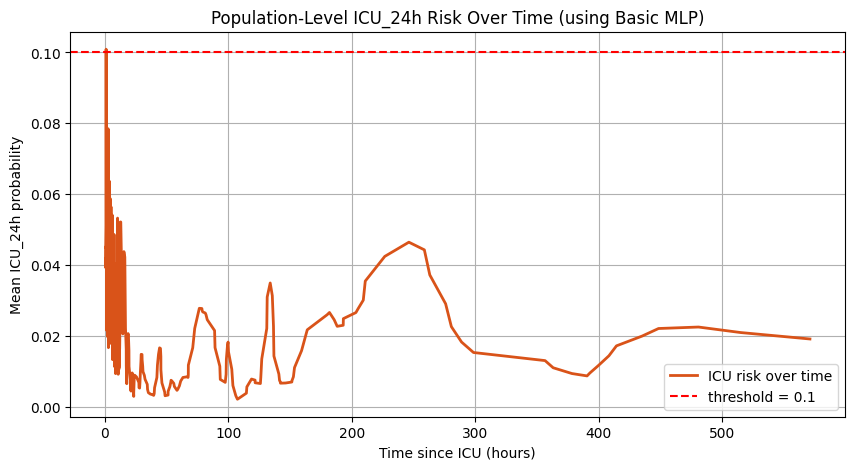

In [325]:

# ----------------------------------------
# 7. plot
# ----------------------------------------
plt.figure(figsize=(10,5))

plt.plot(df_mean["time"], smooth_prob, linewidth=2,   color=(0.8500, 0.3250, 0.0980), label="ICU risk over time")

plt.axhline(0.1, color="red", linestyle="--", label="threshold = 0.1")

plt.xlabel("Time since ICU (hours)")
plt.ylabel("Mean ICU_24h probability")
plt.title("Population-Level ICU_24h Risk Over Time (using Basic MLP)")

plt.legend()
plt.grid()
plt.show()

In [37]:
[c for c in test_df.columns if "time" in c.lower() or "hour" in c.lower() or "ecg" in c.lower()]

['general_ecg_time',
 'general_ecg_no_within_stay',
 'general_intime',
 'general_outtime',
 'general_mortality_hours',
 'general_hosp_dischtime',
 'general_icu_time_hours']

# Class predictions at different thresholds using the BasicEncoderStaticMLP

In [246]:

def evaluate_thresholds(y_true, y_prob, thresholds=np.arange(0.01, 1, 0.01), cFP=1,
    cFN=1):
    
    results = []

    for thr in thresholds:

        y_pred = (y_prob >= thr).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        sensitivity = tp / (tp + fn )   # recall
        specificity = tn / (tn + fp )

        precision = tp / (tp + fp)
        # Cost function
        cost = cFP * fp + cFN * fn

        results.append({
            "threshold": thr,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "precision": precision,
            "False Positive": fp,
            "tp": tp,
            "False Negative": fn,
            "tn": tn,
            "cost": cost
        })

    return pd.DataFrame(results)

In [393]:
encoder.load_state_dict(torch.load("best_realmlp.pt"))
encoder.eval()

BasicEncoderStaticMLP(
  (embeddings): ModuleList(
    (0): Embedding(2, 2)
    (1): Embedding(5, 5)
  )
  (layers): Sequential(
    (0): BatchNorm1d(471, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): Dropout(p=0.25, inplace=False)
    (2): Linear(in_features=471, out_features=128, bias=True)
    (3): ReLU(inplace=True)
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): Dropout(p=0.25, inplace=False)
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): ReLU(inplace=True)
    (8): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Dropout(p=0.25, inplace=False)
    (10): Linear(in_features=128, out_features=128, bias=True)
    (11): ReLU(inplace=True)
    (12): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): Dropout(p=0.5, inplace=False)
    (14): Linear(in_features=128, out_features=4, bias=True)
  )
)

In [493]:
all_preds, all_labels = [], []

with torch.no_grad():

    for cont, cat, labels in val_loader:

        cont = cont.to(device)
        cat  = cat.to(device)

        out = encoder(static=cont, static_cat=cat)

        probs = torch.sigmoid(out["static"])

        all_preds.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_preds  = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

In [494]:
all_results = []

label_names = ['mortality_1d', 'icu_24h', 'cardiac_arrest', 'vasopressors']

for i, label_name in enumerate(label_names):
    mask = ~np.isnan(all_labels[:, i])
    y_true = all_labels[mask, i]
    y_prob = all_preds[mask, i]

    df_thr = evaluate_thresholds(y_true, y_prob, cFP=1, cFN=1)

    # Force a completely independent copy and assign label
    df_temp = df_thr[[
        "threshold",
        "sensitivity",
        "specificity",
        "precision",
        "False Positive",
        "False Negative",
        "cost"
    ]].copy()
    
    df_temp["label"] = label_name

    print("\n")
    print("=" * 60)
    print(label_name)
    print("=" * 60)
    print(df_temp)

    all_results.append(df_temp)

results_df = pd.concat(all_results, ignore_index=True)

# Verify all 4 labels are present
print(results_df["label"].unique())
print(results_df["label"].value_counts())



mortality_1d
    threshold  sensitivity  specificity  precision  False Positive  \
0        0.01        0.600     0.902583   0.040956             562   
1        0.02        0.425     0.960132   0.068826             230   
2        0.03        0.325     0.978852   0.096296             122   
3        0.04        0.225     0.987173   0.108434              74   
4        0.05        0.175     0.991333   0.122807              50   
..        ...          ...          ...        ...             ...   
94       0.95        0.000     1.000000        NaN               0   
95       0.96        0.000     1.000000        NaN               0   
96       0.97        0.000     1.000000        NaN               0   
97       0.98        0.000     1.000000        NaN               0   
98       0.99        0.000     1.000000        NaN               0   

    False Negative  cost         label  
0               16   578  mortality_1d  
1               23   253  mortality_1d  
2               27   

# ROC curve per each label

# 

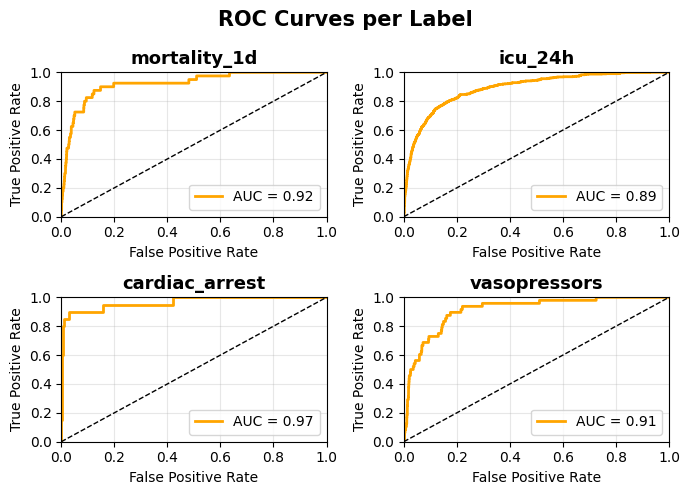

In [255]:
fig, axes = plt.subplots(2, 2, figsize=(7, 5))
axes = axes.flatten()

for i, label_name in enumerate(label_names):
    mask = ~np.isnan(all_labels[:, i])
    y_true = all_labels[mask, i]
    y_prob = all_preds[mask, i]

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    axes[i].plot(fpr, tpr, color="orange", linewidth=2, label=f"AUC = {roc_auc:.2f}")
    axes[i].plot([0, 1], [0, 1], "--", color="black", linewidth=1)

    axes[i].set_title(label_name, fontsize=13, fontweight="bold")
    axes[i].set_xlabel("False Positive Rate")
    axes[i].set_ylabel("True Positive Rate")
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].legend(loc="lower right")
    axes[i].grid(True, alpha=0.3)

plt.suptitle("ROC Curves per Label", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("roc_curves_subplots.png", dpi=150, bbox_inches="tight")
plt.show()

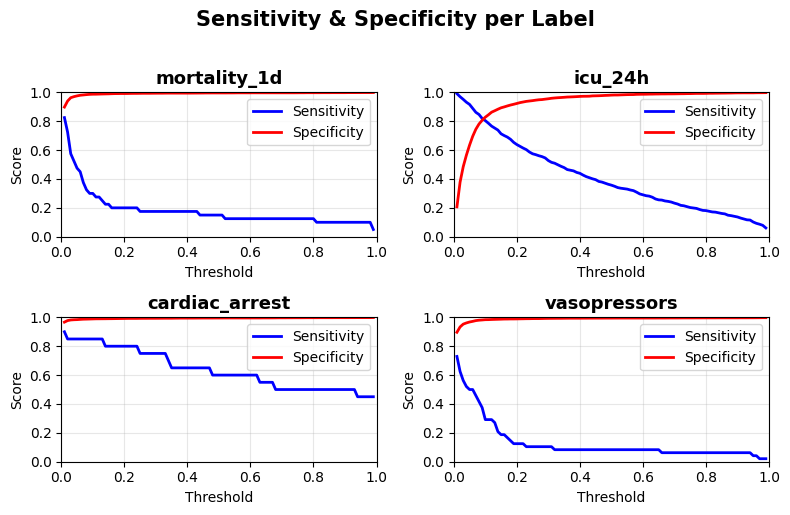

In [250]:


fig, axes = plt.subplots(2, 2, figsize=(8, 5))
axes = axes.flatten()

label_names = ['mortality_1d', 'icu_24h', 'cardiac_arrest', 'vasopressors']

for i, label_name in enumerate(label_names):
    df = results_df[results_df["label"] == label_name]

    axes[i].plot(df["threshold"], df["sensitivity"], label="Sensitivity", color="blue", linewidth=2)
    axes[i].plot(df["threshold"], df["specificity"], label="Specificity", color="red", linewidth=2)

    axes[i].set_title(label_name, fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Threshold")
    axes[i].set_ylabel("Score")
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].legend(loc="best")
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Sensitivity & Specificity per Label", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("sensitivity_specificity_subplots.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
# Filtering the confusion matrix's result to 'icu_24h'
icu_24h_results=results_df[results_df['label']=='icu_24h']
icu_24h_results.columns=['Threshold', 'Sensitivity', 'Specificity', 'Precision',
       'False Positive', 'True Positive', 'False Negative', 'True Negative', 'Cost Function', 'label']
icu_24h_results.drop(columns='label')

,Threshold,Sensitivity,Specificity,Precision,False Positive,True Positive,False Negative,True Negative,Cost Function
0,0.01,0.723404,0.898090,0.054750,587,34,13,5173,600
1,0.02,0.617021,0.934722,0.071605,376,29,18,5384,394
2,0.03,0.553191,0.953819,0.089041,266,26,21,5494,287
3,0.04,0.510638,0.962153,0.099174,218,24,23,5542,241
4,0.05,0.489362,0.968576,0.112745,181,23,24,5579,205
5,0.06,0.489362,0.972917,0.128492,156,23,24,5604,180
6,0.07,0.446809,0.978125,0.142857,126,21,26,5634,152
7,0.08,0.404255,0.980903,0.147287,110,19,28,5650,138
8,0.09,0.361702,0.982465,0.144068,101,17,30,5659,131
9,0.10,0.276596,0.984375,0.126214,90,13,34,5670,124


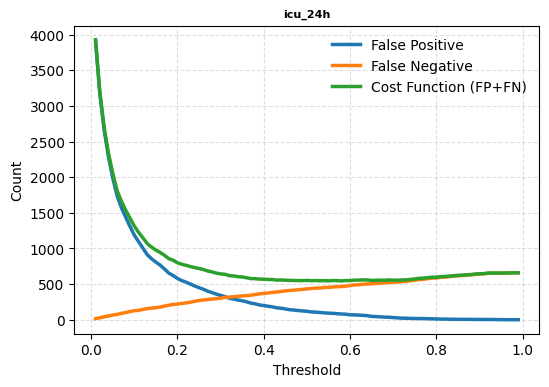

In [496]:
df = results_df[results_df["label"] == "icu_24h"]

x = df["threshold"]
fp = df["False Positive"]
fn = df["False Negative"]
cost_fct = df["cost"]

best_row = df.loc[df["cost"].idxmin()]

plt.figure(figsize=(6, 4))

plt.plot(x, fp, label="False Positive", linewidth=2.5)
plt.plot(x, fn, label="False Negative", linewidth=2.5)
plt.plot(x, cost_fct, label="Cost Function (FP+FN)", linewidth=2.5)

plt.title("icu_24h", fontsize=8, fontweight="bold")
plt.xlabel("Threshold")
plt.ylabel("Count")

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(frameon=False)

plt.show()

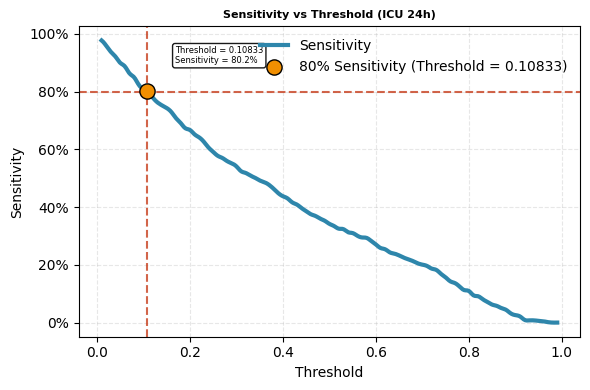

In [497]:
from scipy.interpolate import make_interp_spline

# Filter and sort data
df_plot = df.sort_values("threshold")

x = df_plot["threshold"].values
y = df_plot["sensitivity"].values

# Smooth curve
x_smooth = np.linspace(x.min(), x.max(), 300)
spline = make_interp_spline(x, y, k=3)
y_smooth = spline(x_smooth)

# Find threshold corresponding to 80% sensitivity
target_sens = 0.80

idx = np.argmin(np.abs(y_smooth - target_sens))
thr = x_smooth[idx]
sens = y_smooth[idx]

plt.figure(figsize=(6, 4))

# Sensitivity curve
plt.plot(
    x_smooth,
    y_smooth,
    color="#2E86AB",
    linewidth=3,
    label="Sensitivity"
)

# Mark 80% sensitivity point
plt.scatter(
    thr,
    sens,
    color="#F18F01",
    s=120,
    edgecolor="black",
    zorder=5,
    label=f"80% Sensitivity (Threshold = {thr:.5f})"
)

# Reference lines
plt.axvline(
    thr,
    color="#C73E1D",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)

plt.axhline(
    target_sens,
    color="#C73E1D",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)

# Annotation
plt.annotate(
    f"Threshold = {thr:.5f}\nSensitivity = {sens:.1%}",
    (thr, sens),
    xytext=(20, 20),
    textcoords="offset points",
    fontsize=6,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9)
)

# Titles and labels
plt.title(
    "Sensitivity vs Threshold (ICU 24h)",
    fontsize=8,
    fontweight="bold"
)
plt.xlabel("Threshold")
plt.ylabel("Sensitivity")

# Optional: show y-axis as percentages
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))

plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

# Monte Carlo Dropout 

In [498]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

In [499]:
def mc_dropout_predict(model, test_loader, device, n_samples=50):

    model.train()  # IMPORTANT: keep dropout active

    all_mean_preds = []
    all_uncertainties = []
    all_labels = []

    with torch.no_grad():

        for cont, cat, labels in test_loader:

            cont = cont.to(device)
            cat  = cat.to(device)

            mc_samples = []

            # ----------------------------------------
            # Multiple stochastic forward passes
            # ----------------------------------------
            for _ in range(n_samples):

                out = model(static=cont, static_cat=cat)
                probs = torch.sigmoid(out["static"])

                mc_samples.append(probs.cpu().numpy())

            mc_samples = np.array(mc_samples)

            # -------------
            # 
            # ---------------------------
            # MC statistics
            # ----------------------------------------
            mean_preds = mc_samples.mean(axis=0)
            uncertainty = mc_samples.std(axis=0)

            all_mean_preds.append(mean_preds)
            all_uncertainties.append(uncertainty)
            all_labels.append(labels.numpy())

    all_mean_preds = np.concatenate(all_mean_preds, axis=0)
    all_uncertainties = np.concatenate(all_uncertainties, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    return all_mean_preds, all_uncertainties, all_labels

In [500]:
print("\nRunning Monte Carlo Dropout...")

all_mean_preds, all_uncertainties, y_true = mc_dropout_predict(
    encoder,
    test_loader,
    device,
    n_samples=50
)


Running Monte Carlo Dropout...


In [502]:
y_test = y_true[:, 1]
pred_prob = all_mean_preds[:, 1]

mask = ~np.isnan(y_test)

y_test = y_test[mask]
pred_prob = pred_prob[mask]

In [503]:
pred_prob[(pred_prob > 0.4) & (pred_prob < 0.6)].shape

(282,)

# TP vs FP distribution

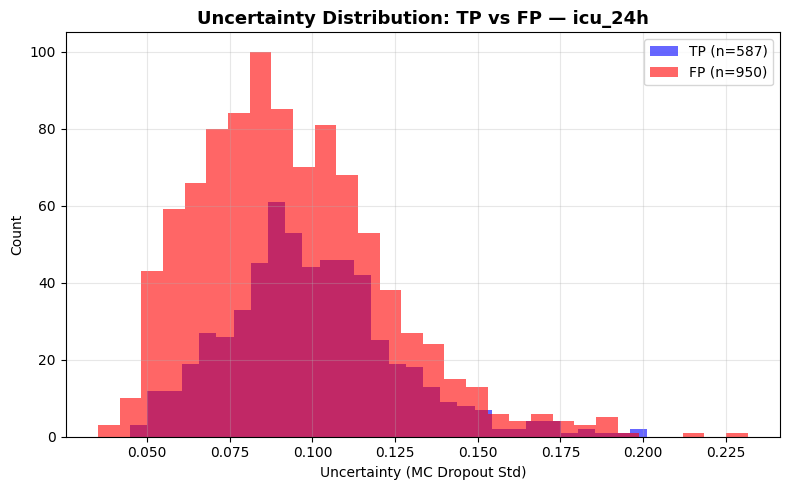

In [322]:
threshold=0.14
mask = ~np.isnan(y_true[:, 1])

y_true_i      = y_true[mask, 1]
mean_preds_i  = all_mean_preds[mask, 1]
uncertainty_i = all_uncertainties[mask, 1]

# Classify into TP and FP
predicted_pos = mean_preds_i >= threshold
tp_mask       = (predicted_pos) & (y_true_i == 1)
fp_mask       = (predicted_pos) & (y_true_i == 0)

tp_uncertainty = uncertainty_i[tp_mask]
fp_uncertainty = uncertainty_i[fp_mask]

plt.figure(figsize=(8, 5))
plt.hist(tp_uncertainty, bins=30, alpha=0.6, color="blue", label=f"TP (n={tp_mask.sum()})")
plt.hist(fp_uncertainty, bins=30, alpha=0.6, color="red",  label=f"FP (n={fp_mask.sum()})")

plt.title("Uncertainty Distribution: TP vs FP — icu_24h", fontsize=13, fontweight="bold")
plt.xlabel("Uncertainty (MC Dropout Std)")
plt.ylabel("Count")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("uncertainty_tp_fp_icu_24h.png", dpi=150, bbox_inches="tight")
plt.show()

In [308]:


y_test = y_true[:, 1]
pred_prob = all_mean_preds[:, 1]

mask = ~np.isnan(y_test)

y_test = y_test[mask]
pred_prob = pred_prob[mask]


y_class = (pred_prob >= 0.14).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_class).ravel()
print(f"Baseline FP = {fp}")

Baseline FP = 950


In [309]:
alpha = 0.14

# --- select class 1 only (same as before) ---
y_test = y_true[:, 1]
pred_prob = all_mean_preds[:, 1]
uncertainty = all_uncertainties[:, 1]

# --- mask NaNs consistently ---
mask = ~np.isnan(y_test)

y_test = y_test[mask]
pred_prob = pred_prob[mask]
uncertainty = uncertainty[mask]

In [310]:
baseline_pred = (pred_prob >= alpha).astype(int)

tn, fp_base, fn, tp = confusion_matrix(y_test, baseline_pred).ravel()

In [311]:
betas = np.linspace(uncertainty.min(), uncertainty.max(), 100)

sensitivities = []
fp_reductions = []

for beta in betas:

    pred = (
        (pred_prob >= alpha) &
        (uncertainty <= beta)
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    sensitivity = tp / (tp + fn)
    fp_reduction = (fp_base - fp) / fp_base if fp_base > 0 else 0

    sensitivities.append(sensitivity)
    fp_reductions.append(fp_reduction)

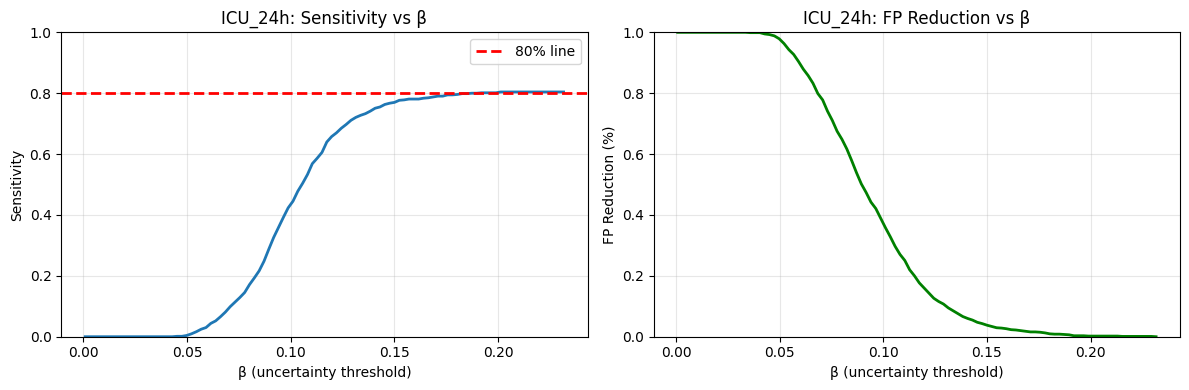

In [317]:


fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# -------------------------
# LEFT: Sensitivity vs β
# -------------------------
ax[0].plot(betas, sensitivities, color="tab:blue", linewidth=2)
ax[0].axhline(0.8, color="red", linestyle="--", linewidth=2, label="80% line")

ax[0].set_title("ICU_24h: Sensitivity vs β")
ax[0].set_xlabel("β (uncertainty threshold)")
ax[0].set_ylabel("Sensitivity")

ax[0].set_ylim(0, 1)
ax[0].grid(True, alpha=0.3)
ax[0].legend()

# -------------------------
# RIGHT: FP Reduction vs β
# -------------------------
ax[1].plot(betas, fp_reductions, color="green", linewidth=2)

ax[1].set_title("ICU_24h: FP Reduction vs β")
ax[1].set_xlabel("β (uncertainty threshold)")
ax[1].set_ylabel("FP Reduction (%)")

ax[1].set_ylim(0, 1)
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

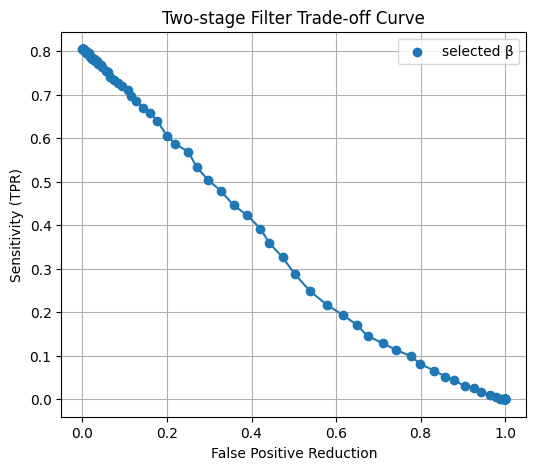

In [320]:
best_idx = np.argmax(fp_reductions)  # or any criterion you prefer

plt.figure(figsize=(6,5))
plt.plot(fp_reductions, sensitivities, marker="o")
plt.scatter(
    fp_reductions[best_idx],
    sensitivities[best_idx],
    label="selected β"
)

plt.xlabel("False Positive Reduction")
plt.ylabel("Sensitivity (TPR)")
plt.title("Two-stage Filter Trade-off Curve")
plt.legend()
plt.grid(True)
plt.show()

# Alarm system using MC dropout

In [159]:
# ----------------------------------------
# 1. MC dropout predictions
# ----------------------------------------
all_probs, all_uncertainties, all_labels = mc_dropout_predict(
    encoder, test_loader, device, n_samples=50
)

In [40]:
# ----------------------------------------
# 2. time column
# ----------------------------------------
time = test_df["general_icu_time_hours"].values

# ----------------------------------------
# 3. filter icu_24h valid rows
# ----------------------------------------
mask = ~np.isnan(all_labels[:, target_idx])

y_prob        = all_probs[mask, target_idx]
y_uncertainty = all_uncertainties[mask, target_idx]
y_time        = time[mask]

# ----------------------------------------
# 4. create dataframe for aggregation
# ----------------------------------------
df_plot = pd.DataFrame({
    "time":        y_time,
    "prob":        y_prob,
    "uncertainty": y_uncertainty
})

In [41]:
# ----------------------------------------
# 5. mean probability + uncertainty per time
# ----------------------------------------
df_mean = df_plot.groupby("time", as_index=False).agg(
    prob        = ("prob",        "mean"),
    uncertainty = ("uncertainty", "mean")
)

df_mean = df_mean.sort_values("time")

# ----------------------------------------
# 6. smooth curves
# ----------------------------------------
from scipy.ndimage import gaussian_filter1d

smooth_prob        = gaussian_filter1d(df_mean["prob"].values,        sigma=2)
smooth_uncertainty = gaussian_filter1d(df_mean["uncertainty"].values, sigma=2)

# Find the FP, FN, TP, TN, sensitivity, specificity at default threshold (0.1238)

In [275]:

results_confusion = []



y_test = y_true[:, 1]
pred_prob = all_mean_preds[:, 1]

mask = ~np.isnan(y_test)

y_test = y_test[mask]
pred_prob = pred_prob[mask]


y_class = (pred_prob >= 0.14).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_class).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

results_confusion.append({
    "target": 'icu_24h',
    "TP": tp,
    "FP": fp,
    "TN": tn,
    "FN": fn,
    "sensitivity": sensitivity,
    "specificity": specificity,
    "n_samples": len(y_test)
})

confusion_df = pd.DataFrame(results_confusion)
print(confusion_df)

    target   TP   FP    TN   FN  sensitivity  specificity  n_samples
0  icu_24h  587  950  4371  143      0.80411     0.821462       6051


# TP, FP, TN, FN at uncertainty = 0.1 

In [335]:
threshold = 0.14

# ----------------------------
# ICU_24h ONLY
# ----------------------------
y_test      = y_true[:, 1]
pred_prob   = all_mean_preds[:, 1]
uncertainty = all_uncertainties[:, 1]

uncertainty_thresholds = [0.05, 0.1, 0.25]

results = []

for u_cut in uncertainty_thresholds:
    for group_name, mask_unc in [
        (f"≤ {u_cut}", uncertainty <= u_cut),
        (f"> {u_cut}", uncertainty > u_cut),
    ]:
        mask = mask_unc & (~np.isnan(y_test))
        y_t  = y_test[mask]
        y_p  = pred_prob[mask]

        y_pred = (y_p >= threshold).astype(int)

        if len(y_t) == 0 or len(np.unique(y_t)) < 2:
            results.append({
                "uncertainty_cutoff" : u_cut,
                "group"              : group_name,
                "n_samples"          : len(y_t),
                "TP": 0, "FP": 0, "TN": 0, "FN": 0,
                "sensitivity"        : np.nan,
                "specificity"        : np.nan,
                "precision"          : np.nan,
                "FDR"                : np.nan,
                "FNR (Miss Rate)"    : np.nan,
                "FPR (Fall-out)"     : np.nan,
                "F1"                 : np.nan,
                "AUC"                : np.nan,
            })
            continue

        tn, fp, fn, tp = confusion_matrix(y_t, y_pred).ravel()

        sensitivity = tp / (tp + fn)        if (tp + fn) > 0 else np.nan  # Recall
        specificity = tn / (tn + fp)        if (tn + fp) > 0 else np.nan
        precision   = tp / (tp + fp)        if (tp + fp) > 0 else np.nan
        fdr         = fp / (fp + tp)        if (fp + tp) > 0 else np.nan  # 1 - precision
        fnr         = fn / (fn + tp)        if (fn + tp) > 0 else np.nan  # Miss rate
        fpr         = fp / (fp + tn)        if (fp + tn) > 0 else np.nan  # Fall-out
        f1          = 2 * tp / (2*tp+fp+fn) if (2*tp+fp+fn) > 0 else np.nan
        auc_score   = roc_auc_score(y_t, y_p)

        results.append({
            "uncertainty_cutoff" : u_cut,
            "group"              : group_name,
            "n_samples"          : len(y_t),
            "TP"                 : tp,
            "FP"                 : fp,
            "TN"                 : tn,
            "FN"                 : fn,
            "sensitivity"        : round(sensitivity, 3),
            "specificity"        : round(specificity, 3),
            "precision"          : round(precision,   3),
            "FDR"                : round(fdr,         3),
            "FNR (Miss Rate)"    : round(fnr,         3),
            "FPR (Fall-out)"     : round(fpr,         3),
            "F1"                 : round(f1,           3),
            "AUC"                : round(auc_score,   3),
        })

df = pd.DataFrame(results)

# Display clearly
print(df.to_string(index=False))

 uncertainty_cutoff  group  n_samples  TP  FP   TN  FN  sensitivity  specificity  precision   FDR  FNR (Miss Rate)  FPR (Fall-out)    F1   AUC
               0.05 ≤ 0.05       4171   3  22 4028 118        0.025        0.995      0.120 0.880            0.975           0.005 0.041 0.753
               0.05 > 0.05       1880 584 928  343  25        0.959        0.270      0.386 0.614            0.041           0.730 0.551 0.808
               0.10  ≤ 0.1       5431 322 595 4371 143        0.692        0.880      0.351 0.649            0.308           0.120 0.466 0.877
               0.10  > 0.1        620 265 355    0   0        1.000        0.000      0.427 0.573            0.000           1.000 0.599 0.720
               0.25 ≤ 0.25       6051 587 950 4371 143        0.804        0.821      0.382 0.618            0.196           0.179 0.518 0.892
               0.25 > 0.25          0   0   0    0   0          NaN          NaN        NaN   NaN              NaN             NaN   NaN   NaN

In [162]:
results = []

for target_idx, target_name in enumerate(lbl_itos_deterioration):

    y_test = y_true[:, target_idx]
    y_pred = all_mean_preds[:, target_idx]
    uncertainty = all_uncertainties[:, target_idx]

    mask = ~np.isnan(y_test)

    y_test = y_test[mask]
    y_pred = y_pred[mask]
    uncertainty = uncertainty[mask]

    if len(np.unique(y_test)) < 2:
        continue

    auroc = roc_auc_score(y_test, y_pred)
    auprc = average_precision_score(y_test, y_pred)
    brier = brier_score_loss(y_test, y_pred)

    results.append({
        "target": target_name,
        "auroc": auroc,
        "auprc": auprc,
        "brier_score": brier,
        "mean_uncertainty": uncertainty.mean(),
        "test_n": len(y_test),
        "positive_rate": y_test.mean()
    })

results_df = pd.DataFrame(results)

results_df.to_csv("realmlp_mc_dropout_results.csv", index=False)

print("\n===== FINAL RESULTS =====")
print(results_df.to_string(index=False))


===== FINAL RESULTS =====
        target    auroc    auprc  brier_score  mean_uncertainty  test_n  positive_rate
  mortality_1d 0.942047 0.203596     0.005894          0.004573    6069       0.006591
       icu_24h 0.892044 0.621920     0.068289          0.042163    6051       0.120641
cardiac_arrest 0.964926 0.414418     0.003703          0.003792    6080       0.004934
  vasopressors 0.887580 0.099151     0.008345          0.005226    6080       0.008882


# calculate 75th, 90th, and 95th certain and uncertain FP, TP, FN, TN

In [163]:
y_test = y_true[:, 1]
pred_prob = all_mean_preds[:, 1]
uncertainty = all_uncertainties[:, 1]

# Percentile thresholds
u_75 = np.percentile(uncertainty[~np.isnan(uncertainty)], 75)
u_90 = np.percentile(uncertainty[~np.isnan(uncertainty)], 90)
u_95 = np.percentile(uncertainty[~np.isnan(uncertainty)], 95)

results = []

for name, mask in [
    ("≤ 75th percentile (certain)", uncertainty <= u_75),
    ("> 75th percentile (uncertain)", uncertainty > u_75),

    ("≤ 90th percentile (certain)", uncertainty <= u_90),
    ("> 90th percentile (uncertain)", uncertainty > u_90),

    ("≤ 95th percentile (certain)", uncertainty <= u_95),
    ("> 95th percentile (uncertain)", uncertainty > u_95),
]:

    m = mask & (~np.isnan(y_test))

    y_t = y_test[m]
    y_p = pred_prob[m]

    y_pred = (y_p >= 0.1238).astype(int)

    if len(y_t) == 0:
        continue

    tn, fp, fn, tp = confusion_matrix(y_t, y_pred).ravel()

    results.append({
        "group": name,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "n_samples": len(y_t),
        "sensitivity": tp / (tp + fn) if (tp + fn) > 0 else np.nan,
        "specificity": tn / (tn + fp) if (tn + fp) > 0 else np.nan,
    })

results_df = pd.DataFrame(results)
print(results_df)

                           group   TP   FP    TN   FN  n_samples  sensitivity  \
0    ≤ 75th percentile (certain)   44  242  4148  125       4559     0.260355   
1  > 75th percentile (uncertain)  554  876    55    7       1492     0.987522   
2    ≤ 90th percentile (certain)  345  778  4201  132       5456     0.723270   
3  > 90th percentile (uncertain)  253  340     2    0        595     1.000000   
4    ≤ 95th percentile (certain)  480  937  4203  132       5752     0.784314   
5  > 95th percentile (uncertain)  118  181     0    0        299     1.000000   

   specificity  
0     0.944875  
1     0.059076  
2     0.843744  
3     0.005848  
4     0.817704  
5     0.000000  


In [342]:
# ----------------------------------------
# align lengths upfront
# ----------------------------------------
min_len = min(len(y_test), len(pred_prob), len(uncertainty))

y_test_v      = y_test[:min_len]
pred_prob_v   = pred_prob[:min_len]
uncertainty_v = uncertainty[:min_len]

valid_mask    = ~np.isnan(y_test_v)

y_test_v      = y_test_v[valid_mask]
pred_prob_v   = pred_prob_v[valid_mask]
uncertainty_v = uncertainty_v[valid_mask]

# ----------------------------------------
# percentile thresholds
# ----------------------------------------
u_75 = np.percentile(uncertainty_v, 75)
u_90 = np.percentile(uncertainty_v, 90)
u_95 = np.percentile(uncertainty_v, 95)

results = []

for name, mask in [
    ("≤ 75th percentile (certain)", uncertainty_v <= u_75),
    ("> 75th percentile",                uncertainty_v >  u_75),

    ("≤ 90th percentile (certain)", uncertainty_v <= u_90),
    ("> 90th percentile",                uncertainty_v >  u_90),

    ("≤ 95th percentile (certain)", uncertainty_v <= u_95),
    ("> 95th percentile (uncertain)", uncertainty_v > u_95),
]:
    y_t = y_test_v[mask]
    y_p = pred_prob_v[mask]

    y_pred = (y_p >= 0.14).astype(int)

    if len(y_t) == 0:
        continue

    tn, fp, fn, tp = confusion_matrix(y_t, y_pred).ravel()

    n          = len(y_t)
    n_pos      = tp + fn
    n_neg      = tn + fp
    n_pred_pos = tp + fp

    results.append({
        "group"                   : name,
        "n"                       : n,
        "prevalence% (pos/n)"     : round(100 * n_pos / n, 1),
        "sensitivity% (TP/pos)"   : round(100 * tp / n_pos, 1)      if n_pos      > 0 else np.nan,
        "precision% (TP/(TP+FP))" : round(100 * tp / n_pred_pos, 1) if n_pred_pos > 0 else np.nan,
        "FDR% (FP/(TP+FP))"       : round(100 * fp / n_pred_pos, 1) if n_pred_pos > 0 else np.nan,
        "FN/(FN+TN)%"             : round(100 * fn / (fn + tn), 1)  if (fn + tn)  > 0 else np.nan,
        "fall-out% (FP/neg)"      : round(100 * fp / n_neg, 1)       if n_neg      > 0 else np.nan,
        "specificity% (TN/neg)"   : round(100 * tn / n_neg, 1)       if n_neg      > 0 else np.nan,
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                        group    n  prevalence% (pos/n)  sensitivity% (TP/pos)  precision% (TP/(TP+FP))  FDR% (FP/(TP+FP))  FN/(FN+TN)%  fall-out% (FP/neg)  specificity% (TN/neg)
  ≤ 75th percentile (certain) 4538                  3.7                   20.1                     22.7               77.3          3.1                 2.7                   97.3
            > 75th percentile 1513                 37.1                   98.6                     39.9               60.1          6.3                87.6                   12.4
  ≤ 90th percentile (certain) 5446                  8.6                   69.4                     34.9               65.1          3.2                12.2                   87.8
            > 90th percentile  605                 43.3                  100.0                     43.3               56.7          NaN               100.0                    0.0
  ≤ 95th percentile (certain) 5748                 10.5                   76.4                     37.5  

# Expected Calibration Error 

In [164]:
def expected_calibration_error(y_true, y_prob, n_bins=10):

    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    bins = np.linspace(0.0, 1.0, n_bins + 1)

    ece = 0.0
    n = len(y_true)

    for i in range(n_bins):

        bin_lower = bins[i]
        bin_upper = bins[i + 1]

        if i == n_bins - 1:
            mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            mask = (y_prob >= bin_lower) & (y_prob < bin_upper)

        if np.sum(mask) == 0:
            continue

        bin_acc = np.mean(y_true[mask])
        bin_conf = np.mean(y_prob[mask])

        weight = np.sum(mask) / n

        ece += weight * abs(bin_acc - bin_conf)

    return ece


# ============================
# ICU_24h ECE computation
# ============================

# extract ICU_24h only
y_test = y_true[:, 1]
y_prob = all_mean_preds[:, 1]

# remove NaNs
mask = ~np.isnan(y_test)

y_test = y_test[mask]
y_prob = y_prob[mask]

# ensure numpy arrays
y_test = np.asarray(y_test)
y_prob = np.asarray(y_prob)

# compute ECE
ece = expected_calibration_error(y_test, y_prob, n_bins=10)

print("ECE (ICU_24h):", ece)

ECE (ICU_24h): 0.019825088889899083


In [ ]:
def expected_calibration_error_and_bins(y_true, y_prob, n_bins=15):

    bins = np.linspace(0, 1, n_bins + 1)

    bin_acc = []
    bin_conf = []
    bin_sizes = []

    ece = 0.0
    n = len(y_true)

    for i in range(n_bins):

        left, right = bins[i], bins[i + 1]

        if i == n_bins - 1:
            mask = (y_prob >= left) & (y_prob <= right)
        else:
            mask = (y_prob >= left) & (y_prob < right)

        if np.sum(mask) == 0:
            bin_acc.append(np.nan)
            bin_conf.append(np.nan)
            bin_sizes.append(0)
            continue

        acc = np.mean(y_true[mask])
        conf = np.mean(y_prob[mask])

        weight = np.sum(mask) / n
        ece += weight * abs(acc - conf)

        bin_acc.append(acc)
        bin_conf.append(conf)
        bin_sizes.append(np.sum(mask))

    return ece, bins, np.array(bin_acc), np.array(bin_conf), np.array(bin_sizes)


# ============================
# ICU_24h data
# ============================
y_true_icu = y_true[:, 1]
y_prob_icu = all_mean_preds[:, 1]

mask = ~np.isnan(y_true_icu)

y_true_icu = y_true_icu[mask]
y_prob_icu = y_prob_icu[mask]

# ============================
# compute ECE + bins
# ============================
ece, bins, acc, conf, sizes = expected_calibration_error_and_bins(
    y_true_icu, y_prob_icu, n_bins=15
)

centers = (bins[:-1] + bins[1:]) / 2

# ============================
# plot
# ============================
plt.figure(figsize=(7, 6))

# perfect calibration line
plt.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)

# binned reliability (red step-like curve)
plt.plot(centers, acc, color='red', linewidth=2, label="Model")

# optional: confidence curve
plt.plot(centers, conf, color='black', linestyle='--', alpha=0.7, label="Confidence")

# bars (bin frequency shading like your image)
plt.bar(centers, acc, width=0.06, alpha=0.2, color='red')

# ECE annotation
plt.text(
    0.05, 0.9,
    f"ECE: {ece:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12
)

plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Reliability Diagram (ICU_24h)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

print("ECE:", ece)

IndexError: boolean index did not match indexed array along axis 0; size of axis is 980 but size of corresponding boolean axis is 6080

# Calculate ECE for each class 

In [365]:
all_mean_preds

array([0.20222358, 0.69362974, 0.01786159, ..., 0.03077725, 0.009604  ,
       0.06007001], shape=(6080,), dtype=float32)

In [369]:
y_true_icu = y_true[:, 1]
y_prob_icu = all_mean_preds[:, 1]

mask = ~np.isnan(y_true_icu)

y_true_icu = y_true_icu[mask]
y_prob_icu = y_prob_icu[mask]

In [370]:
y_true_pos = y_true_icu[y_true_icu == 1]
y_prob_pos = y_prob_icu[y_true_icu == 1]

y_true_neg = y_true_icu[y_true_icu == 0]
y_prob_neg = y_prob_icu[y_true_icu == 0]

In [408]:
all_mean_preds

array([0.14947921, 0.6368514 , 0.00727353, ..., 0.03828207, 0.00728841,
       0.04117455], shape=(6080,), dtype=float32)

In [450]:
y_true_icu = y_true[:, 1]
y_prob_icu = all_mean_preds[:, 1]

mask = ~np.isnan(y_true_icu)

y_true_icu = y_true_icu[mask]
y_prob_icu = y_prob_icu[mask]

# split by prediction, NOT by true label
mask_high = y_prob_icu >= 0.5
mask_low  = y_prob_icu < 0.5

ece_high, bins, acc_high, conf_high, _ = expected_calibration_error_and_bins(
    y_true_icu[mask_high],
    y_prob_icu[mask_high],
    n_bins=15
)

ece_low, _, acc_low, conf_low, _ = expected_calibration_error_and_bins(
    y_true_icu[mask_low],
    y_prob_icu[mask_low],
    n_bins=15
)

In [372]:


# Simulate dummy data for y_true and all_mean_preds
np.random.seed(42)
n_samples = 1000
# True labels (binary)
y_true_icu = np.random.binomial(1, 0.4, n_samples)
# Predicted probabilities (imperfectly calibrated)
y_prob_icu = np.clip(y_true_icu * 0.6 + np.random.uniform(0, 0.4, n_samples), 0, 1)

def expected_calibration_error_and_bins(y_true, y_prob, n_bins=15):
    bins = np.linspace(0, 1, n_bins + 1)
    bin_acc = []
    bin_conf = []
    bin_sizes = []
    ece = 0.0
    n = len(y_true)
    for i in range(n_bins):
        left, right = bins[i], bins[i + 1]
        if i == n_bins - 1:
            mask = (y_prob >= left) & (y_prob <= right)
        else:
            mask = (y_prob >= left) & (y_prob < right)
        if np.sum(mask) == 0:
            bin_acc.append(np.nan)
            bin_conf.append(np.nan)
            bin_sizes.append(0)
            continue
        acc = np.mean(y_true[mask])
        conf = np.mean(y_prob[mask])
        weight = np.sum(mask) / n
        ece += weight * abs(acc - conf)
        bin_acc.append(acc)
        bin_conf.append(conf)
        bin_sizes.append(np.sum(mask))
    return ece, bins, np.array(bin_acc), np.array(bin_conf), np.array(bin_sizes)

# Incorrect way (positives only)
mask_pos = (y_true_icu == 1)
y_true_pos = y_true_icu[mask_pos]
y_prob_pos = y_prob_icu[mask_pos]
ece_pos, bins_pos, acc_pos, conf_pos, sizes_pos = expected_calibration_error_and_bins(y_true_pos, y_prob_pos, n_bins=10)

# Correct way (all samples)
ece_all, bins_all, acc_all, conf_all, sizes_all = expected_calibration_error_and_bins(y_true_icu, y_prob_icu, n_bins=10)

print("ECE (positives only):", ece_pos)
print("Accuracies (positives only):", acc_pos)
print("ECE (all samples):", ece_all)
print("Accuracies (all samples):", acc_all)

ECE (positives only): 0.19181925954137538
Accuracies (positives only): [nan nan nan nan nan nan  1.  1.  1.  1.]
ECE (all samples): 0.19647502895670602
Accuracies (all samples): [ 0.  0.  0.  0. nan nan  1.  1.  1.  1.]


In [469]:
all_mean_preds=all_mean_preds[:, 1]
y_true_icu = y_true[:, 1]

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

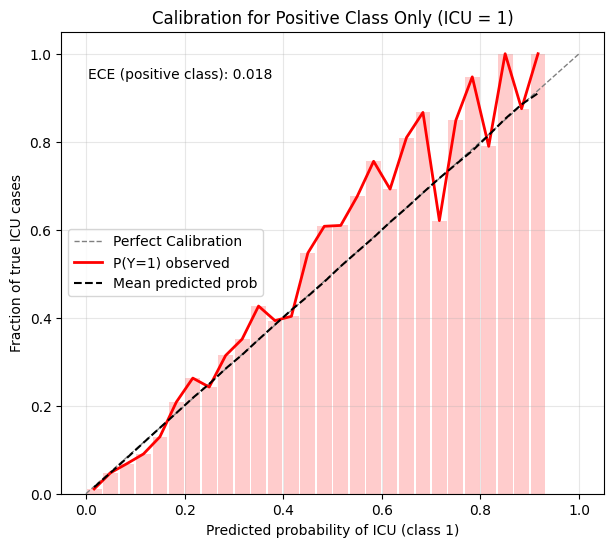

In [482]:
import numpy as np
import matplotlib.pyplot as plt

# ============================
# Data
# ============================

y_prob_icu = np.array(pred_prob)
y_true_icu = np.array(y_test)

# align lengths
min_len = len(y_prob_icu)
y_true_icu = y_true_icu[:min_len]
y_prob_icu = y_prob_icu[:min_len]

# OPTIONAL: remove NaNs safely
mask_valid = ~np.isnan(y_prob_icu) & ~np.isnan(y_true_icu)
y_true_icu = y_true_icu[mask_valid]
y_prob_icu = y_prob_icu[mask_valid]

# ============================
# Positive-class calibration (ONLY class 1)
# ============================

def expected_calibration_error_positive_class(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)

    bin_frac_positive = []
    bin_conf = []
    bin_sizes = []

    ece = 0.0
    n = len(y_true)

    for i in range(n_bins):
        left, right = bins[i], bins[i + 1]

        if i == n_bins - 1:
            bin_mask = (y_prob >= left) & (y_prob <= right)
        else:
            bin_mask = (y_prob >= left) & (y_prob < right)

        if np.sum(bin_mask) == 0:
            bin_frac_positive.append(np.nan)
            bin_conf.append(np.nan)
            bin_sizes.append(0)
            continue

        # KEY CHANGE: focus ONLY on class 1 rate
        frac_pos = np.mean(y_true[bin_mask] == 1)
        conf = np.mean(y_prob[bin_mask])

        weight = np.sum(bin_mask) / n
        ece += weight * abs(frac_pos - conf)

        bin_frac_positive.append(frac_pos)
        bin_conf.append(conf)
        bin_sizes.append(np.sum(bin_mask))

    return ece, bins, np.array(bin_frac_positive), np.array(bin_conf), np.array(bin_sizes)

# ============================
# Compute
# ============================

n_bins = 30

ece_pos, bins, frac_pos, conf, sizes = expected_calibration_error_positive_class(
    y_true_icu,
    y_prob_icu,
    n_bins=n_bins
)

centers = (bins[:-1] + bins[1:]) / 2
bin_width = 1.0 / n_bins

# ============================
# Plot
# ============================

plt.figure(figsize=(7, 6))

# perfect calibration line
plt.plot([0, 1], [0, 1], '--', color='gray', linewidth=1, label="Perfect Calibration")

# reliability curve (positive class)
plt.plot(centers, frac_pos, color='red', linewidth=2, label="P(Y=1) observed")
plt.plot(centers, conf, color='black', linestyle='--', label="Mean predicted prob")

# bars
plt.bar(centers, frac_pos, width=bin_width * 0.9, alpha=0.2, color='red')

# ECE
plt.text(
    0.05, 0.90,
    f"ECE (positive class): {ece_pos:.3f}",
    transform=plt.gca().transAxes
)

plt.xlabel("Predicted probability of ICU (class 1)")
plt.ylabel("Fraction of true ICU cases")
plt.title("Calibration for Positive Class Only (ICU = 1)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

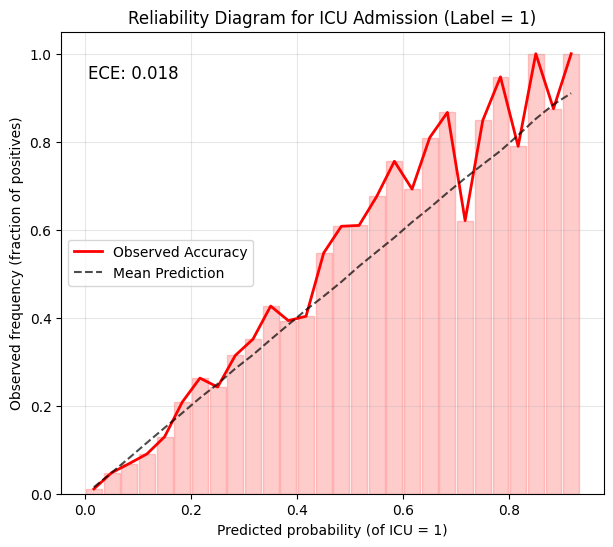

In [492]:
# ============================
# ICU_24h data
# ============================


# 1. Truncate y_true_icu to match the length of your predictions (6051)
min_len = len(y_prob_icu)
y_true_icu = y_true_icu[:min_len]

# 2. Now that lengths match, safely filter out NaNs from both
mask = (~np.isnan(y_true_icu)) & (~np.isnan(y_prob_icu))
y_true_icu = y_true_icu[mask]
y_prob_icu = y_prob_icu[mask]

# ============================
# ECE function
# ============================
def expected_calibration_error_and_bins(y_true, y_prob, n_bins=15):
    bins = np.linspace(0, 1, n_bins + 1)

    bin_acc = []
    bin_conf = []
    bin_sizes = []

    ece = 0.0
    n = len(y_true)

    for i in range(n_bins):
        left, right = bins[i], bins[i + 1]

        if i == n_bins - 1:
            mask = (y_prob >= left) & (y_prob <= right)
        else:
            mask = (y_prob >= left) & (y_prob < right)

        if np.sum(mask) == 0:
            bin_acc.append(np.nan)
            bin_conf.append(np.nan)
            bin_sizes.append(0)
            continue

        acc = np.mean(y_true[mask])
        conf = np.mean(y_prob[mask])

        weight = np.sum(mask) / n
        ece += weight * abs(acc - conf)

        bin_acc.append(acc)
        bin_conf.append(conf)
        bin_sizes.append(np.sum(mask))

    return ece, bins, np.array(bin_acc), np.array(bin_conf), np.array(bin_sizes)

# ============================
# Compute ECE
# ============================
n_bins = 30
ece, bins, acc, conf, sizes = expected_calibration_error_and_bins(
    y_true_icu,
    y_prob_icu,
    n_bins=n_bins
)

centers = (bins[:-1] + bins[1:]) / 2
bin_width = 1.0 / n_bins  

# ============================
# Plot
# ============================
plt.figure(figsize=(7, 6))

# Perfectly Calibrated reference line (Fixed syntax error)
#plt.plot(,, '--', color='gray', linewidth=1, label="Perfectly Calibrated")

# Accuracy vs Confidence lines
plt.plot(centers, acc, color='red', linewidth=2, label="Observed Accuracy")
plt.plot(centers, conf, color='black', linestyle='--', alpha=0.7, label="Mean Prediction")

# Cleanly spaced bars showing the accuracy per bin
plt.bar(centers, acc, width=bin_width * 0.9, alpha=0.2, color='red', edgecolor='red')

plt.text(
    0.05, 0.90,
    f"ECE: {ece:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12
)

plt.xlabel("Predicted probability (of ICU = 1)")
plt.ylabel("Observed frequency (fraction of positives)")
plt.title("Reliability Diagram for ICU Admission (Label = 1)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

ECE before : 0.004
ECE after  : 0.013


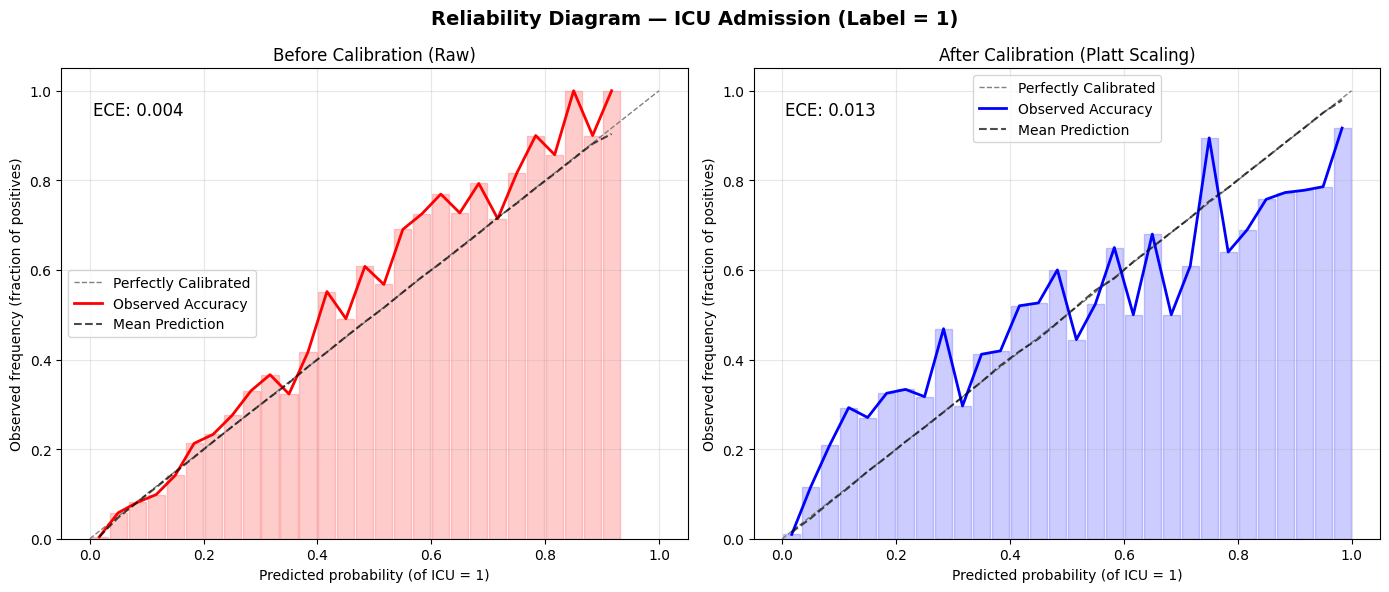

In [466]:
from sklearn.linear_model import LogisticRegression

# ============================
# Use exact same variables as your working code
# y_prob_icu and y_true_icu are already cleaned
# from your previous cell — do NOT redefine them
# ============================

# ============================
# Platt Scaling
# fit on first 50%, apply to full data
# ============================
split      = len(y_true_icu) // 2
platt      = LogisticRegression()
platt.fit(y_prob_icu[:split].reshape(-1, 1), y_true_icu[:split])
y_prob_cal = platt.predict_proba(y_prob_icu.reshape(-1, 1))[:, 1]

# ============================
# ECE before and after
# ============================
n_bins = 30

ece_before, bins, acc_before, conf_before, _ = expected_calibration_error_and_bins(
    y_true_icu, y_prob_icu, n_bins=n_bins
)
ece_after,  bins, acc_after,  conf_after,  _ = expected_calibration_error_and_bins(
    y_true_icu, y_prob_cal,  n_bins=n_bins
)

print(f"ECE before : {ece_before:.3f}")
print(f"ECE after  : {ece_after:.3f}")

centers      = (bins[:-1] + bins[1:]) / 2
bin_width    = 1.0 / n_bins
valid_before = ~np.isnan(acc_before)
valid_after  = ~np.isnan(acc_after)

# ============================
# Plot — Before vs After
# ============================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---------- BEFORE ----------
axes[0].plot([0, 1], [0, 1], '--', color='gray', linewidth=1,
             label="Perfectly Calibrated")
axes[0].plot(centers[valid_before], acc_before[valid_before],
             color='red', linewidth=2, label="Observed Accuracy")
axes[0].plot(centers[valid_before], conf_before[valid_before],
             color='black', linestyle='--', alpha=0.7, label="Mean Prediction")
axes[0].bar(centers[valid_before], acc_before[valid_before],
            width=bin_width * 0.9, alpha=0.2, color='red', edgecolor='red')
axes[0].text(0.05, 0.90, f"ECE: {ece_before:.3f}",
             transform=axes[0].transAxes, fontsize=12)
axes[0].set_xlabel("Predicted probability (of ICU = 1)")
axes[0].set_ylabel("Observed frequency (fraction of positives)")
axes[0].set_title("Before Calibration (Raw)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ---------- AFTER ----------
axes[1].plot([0, 1], [0, 1], '--', color='gray', linewidth=1,
             label="Perfectly Calibrated")
axes[1].plot(centers[valid_after], acc_after[valid_after],
             color='blue', linewidth=2, label="Observed Accuracy")
axes[1].plot(centers[valid_after], conf_after[valid_after],
             color='black', linestyle='--', alpha=0.7, label="Mean Prediction")
axes[1].bar(centers[valid_after], acc_after[valid_after],
            width=bin_width * 0.9, alpha=0.2, color='blue', edgecolor='blue')
axes[1].text(0.05, 0.90, f"ECE: {ece_after:.3f}",
             transform=axes[1].transAxes, fontsize=12)
axes[1].set_xlabel("Predicted probability (of ICU = 1)")
axes[1].set_ylabel("Observed frequency (fraction of positives)")
axes[1].set_title("After Calibration (Platt Scaling)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Reliability Diagram — ICU Admission (Label = 1)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("calibration_before_after_icu_24h.png", dpi=150, bbox_inches="tight")
plt.show()

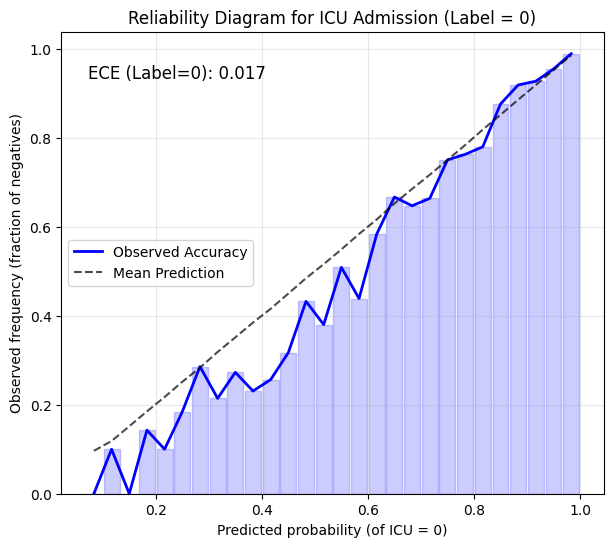

In [464]:
import numpy as np
import matplotlib.pyplot as plt

# ============================
# ICU_24h data (Inverted for Label = 0)
# ============================
# 1. Align lengths first (using the 6051 matched samples from before)
min_len = len(all_mean_preds)
y_prob_icu_1 = all_mean_preds[:,1]
y_true_icu_1 = y_true[:, 1][:min_len]

# 2. Invert both arrays so we focus on the negative class (Label = 0)
y_true_icu_0 = 1 - y_true_icu_1
y_prob_icu_0 = 1 - y_prob_icu_1

# 3. Safely filter out NaNs
mask = (~np.isnan(y_true_icu_0)) & (~np.isnan(y_prob_icu_0))
y_true_icu_0 = y_true_icu_0[mask]
y_prob_icu_0 = y_prob_icu_0[mask]

# ============================
# Compute ECE for Label = 0
# ============================
n_bins = 30
ece_0, bins_0, acc_0, conf_0, sizes_0 = expected_calibration_error_and_bins(
    y_true_icu_0,
    y_prob_icu_0,
    n_bins=n_bins
)

centers_0 = (bins_0[:-1] + bins_0[1:]) / 2
bin_width = 1.0 / n_bins  

# ============================
# Plot (Label = 0)
# ============================
plt.figure(figsize=(7, 6))

# Perfectly Calibrated reference line
#plt.plot(,, '--', color='gray', linewidth=1, label="Perfectly Calibrated")

# Accuracy vs Confidence lines (Using Blue for negatives)
plt.plot(centers_0, acc_0, color='blue', linewidth=2, label="Observed Accuracy")
plt.plot(centers_0, conf_0, color='black', linestyle='--', alpha=0.7, label="Mean Prediction")

# Cleanly spaced bars showing the accuracy per bin
plt.bar(centers_0, acc_0, width=bin_width * 0.9, alpha=0.2, color='blue', edgecolor='blue')

plt.text(
    0.05, 0.90,
    f"ECE (Label=0): {ece_0:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12
)

plt.xlabel("Predicted probability (of ICU = 0)")
plt.ylabel("Observed frequency (fraction of negatives)")
plt.title("Reliability Diagram for ICU Admission (Label = 0)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

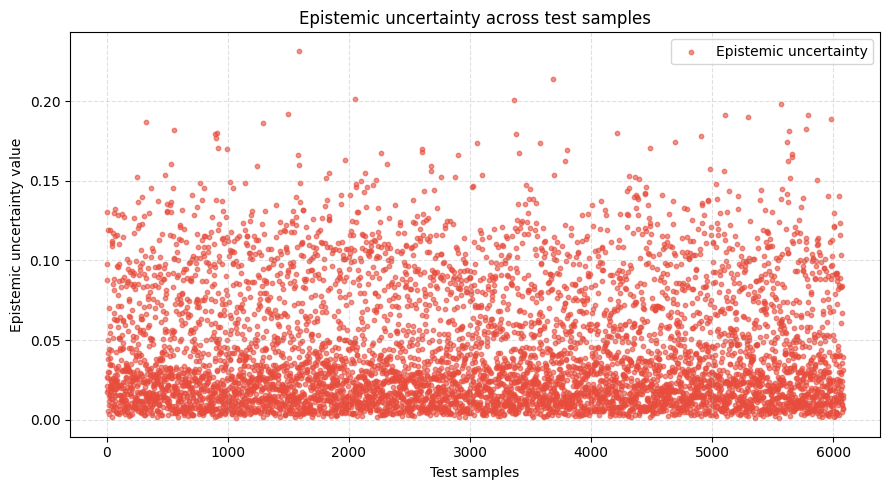

In [336]:
x = np.arange(1, 6081)

plt.figure(figsize=(9, 5))

# Scatter plot for uncertainty
plt.scatter(x, uncertainty, 
            s=10, 
            alpha=0.6, 
            color="#e74c3c",  # attractive red
            label="Epistemic uncertainty")

plt.xlabel("Test samples")
plt.ylabel("Epistemic uncertainty value")
plt.title("Epistemic uncertainty across test samples")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Split the data into two subsets using a 90% uncertainty (k = 0.9).

In [141]:
results1 = []
subset_samples = {}  # <-- store sample indices + values

uncertainty_threshold = 0.1

for target_idx, target_name in enumerate(lbl_itos_deterioration[:2]):

    y_test = y_true[:, target_idx]
    y_pred = all_mean_preds[:, target_idx]
    uncertainty = all_uncertainties[:, target_idx]

    mask = ~np.isnan(y_test)

    # original indices BEFORE filtering
    idx_all = np.arange(len(y_test))[mask]

    y_test = y_test[mask]
    y_pred = y_pred[mask]
    uncertainty = uncertainty[mask]

    for group_name, group_mask in [
        ("uncertainty ≤ 0.1", uncertainty <= uncertainty_threshold),
        ("uncertainty > 0.1", uncertainty > uncertainty_threshold),
    ]:

        idx_group = idx_all[group_mask]

        y_test_group = y_test[group_mask]
        y_pred_group = y_pred[group_mask]
        uncertainty_group = uncertainty[group_mask]

        # store samples for later inspection
        subset_samples[(target_name, group_name)] = {
            "indices": idx_group,
            "y_true": y_test_group,
            "y_pred": y_pred_group,
            "uncertainty": uncertainty_group
        }

        if len(y_test_group) == 0 or len(np.unique(y_test_group)) < 2:
            continue

        auroc = roc_auc_score(y_test_group, y_pred_group)
        auprc = average_precision_score(y_test_group, y_pred_group)
        brier = brier_score_loss(y_test_group, y_pred_group)

        results1.append({
            "target": target_name,
            "group": group_name,
            "auroc": auroc,
            "auprc": auprc,
            "brier_score": brier,
            "mean_uncertainty": uncertainty_group.mean(),
            "test_n": len(y_test_group),
            "positive_rate": y_test_group.mean()
        })
results_df = pd.DataFrame(results1)

#results_df.to_csv(
#    "realmlp_mc_dropout_results_by_uncertainty.csv",
 #   index=False
#)

print("\n===== RESULTS BY UNCERTAINTY =====")
print(results_df.to_string(index=False))


===== RESULTS BY UNCERTAINTY =====
      target             group    auroc    auprc  brier_score  mean_uncertainty  test_n  positive_rate
mortality_1d uncertainty ≤ 0.1 0.923662 0.100997     0.004727          0.005023    6041       0.004966
mortality_1d uncertainty > 0.1 0.622222 0.446218     0.231808          0.138897      28       0.357143
     icu_24h uncertainty ≤ 0.1 0.873544 0.548320     0.061478          0.032423    5691       0.096468
     icu_24h uncertainty > 0.1 0.684836 0.677634     0.227797          0.115618     360       0.502778


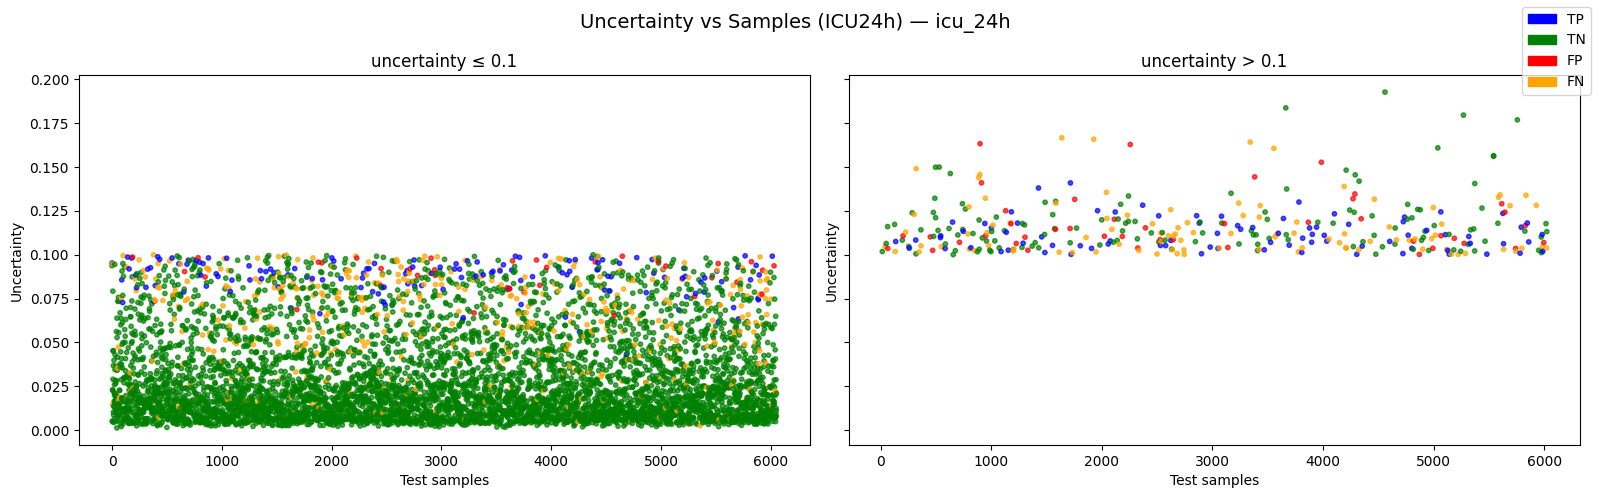

In [87]:


# -----------------------------
# SECOND LABEL ONLY (ICU24h)
# -----------------------------
target_idx = 1
target_name = lbl_itos_deterioration[target_idx]

y_true_l = y_true[:, target_idx]
y_prob_l = all_mean_preds[:, target_idx]
unc_l = all_uncertainties[:, target_idx]

mask = ~np.isnan(y_true_l)

y_true_l = y_true_l[mask]
y_prob_l = y_prob_l[mask]
unc_l = unc_l[mask]

# -----------------------------
# BINARY PREDICTION (needed for TP/FP/FN/TN)
# -----------------------------
y_pred_l = (y_prob_l >= 0.50).astype(int)

# -----------------------------
# CLASSIFY EACH SAMPLE
# -----------------------------
colors = []

for yt, yp in zip(y_true_l, y_pred_l):
    if yt == 1 and yp == 1:
        colors.append("blue")    # TP
    elif yt == 0 and yp == 0:
        colors.append("green")   # TN
    elif yt == 0 and yp == 1:
        colors.append("red")     # FP
    else:
        colors.append("orange")  # FN

colors = np.array(colors)

# -----------------------------
# SPLIT BY UNCERTAINTY
# -----------------------------
low_mask = unc_l <= 0.1
high_mask = unc_l > 0.1

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

groups = [
    ("uncertainty ≤ 0.1", low_mask, axes[0]),
    ("uncertainty > 0.1", high_mask, axes[1])
]

x = np.arange(len(y_true_l))

for title, m, ax in groups:

    ax.scatter(
        x[m],
        unc_l[m],
        c=colors[m],
        s=10,
        alpha=0.7
    )

    ax.set_title(title)
    ax.set_xlabel("Test samples")
    ax.set_ylabel("Uncertainty")

# legend (manual)
import matplotlib.patches as mpatches

legend_items = [
    mpatches.Patch(color="blue", label="TP"),
    mpatches.Patch(color="green", label="TN"),
    mpatches.Patch(color="red", label="FP"),
    mpatches.Patch(color="orange", label="FN"),
]

fig.legend(handles=legend_items, loc="upper right")

fig.suptitle(f"Uncertainty vs Samples (ICU24h) — {target_name}", fontsize=14)

plt.tight_layout()
plt.show()

# Split the data into two subsets using a 95% uncertainty (k = 0.95).

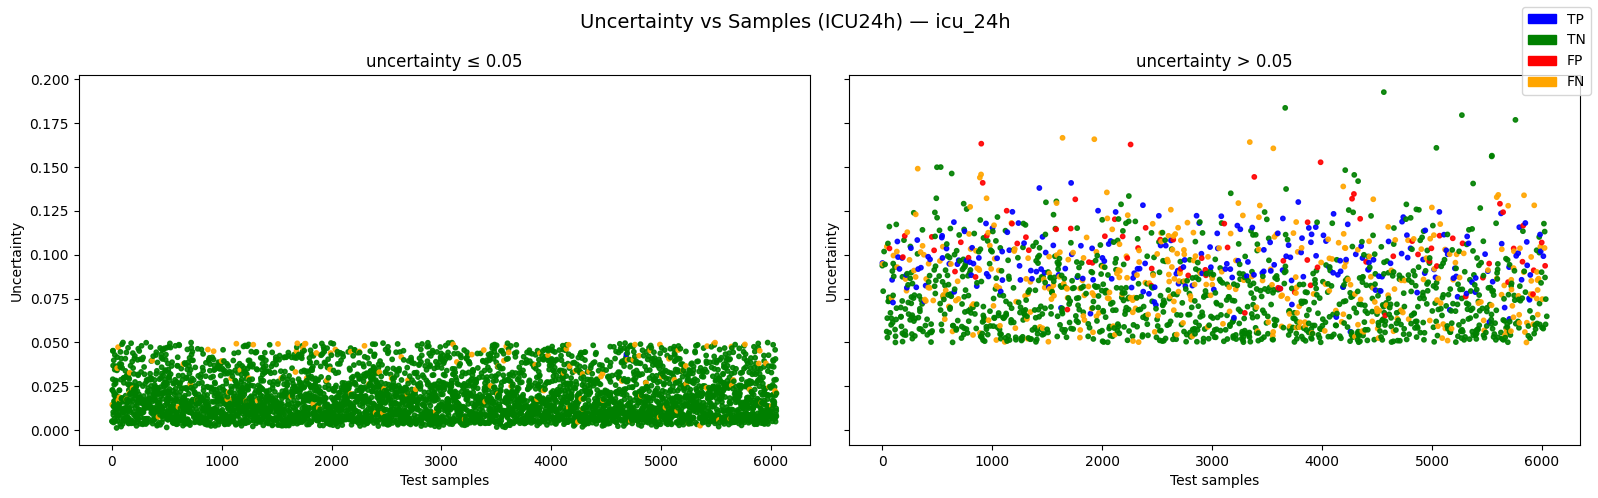

In [89]:


# -----------------------------
# SECOND LABEL ONLY (ICU24h)
# -----------------------------
target_idx = 1
target_name = lbl_itos_deterioration[target_idx]

y_true_l = y_true[:, target_idx]
y_prob_l = all_mean_preds[:, target_idx]
unc_l = all_uncertainties[:, target_idx]

mask = ~np.isnan(y_true_l)

y_true_l = y_true_l[mask]
y_prob_l = y_prob_l[mask]
unc_l = unc_l[mask]

# -----------------------------
# BINARY PREDICTION (needed for TP/FP/FN/TN)
# -----------------------------
y_pred_l = (y_prob_l >= 0.50).astype(int)

# -----------------------------
# CLASSIFY EACH SAMPLE
# -----------------------------
colors = []

for yt, yp in zip(y_true_l, y_pred_l):
    if yt == 1 and yp == 1:
        colors.append("blue")    # TP
    elif yt == 0 and yp == 0:
        colors.append("green")   # TN
    elif yt == 0 and yp == 1:
        colors.append("red")     # FP
    else:
        colors.append("orange")  # FN

colors = np.array(colors)

# -----------------------------
# SPLIT BY UNCERTAINTY
# -----------------------------
low_mask = unc_l <= 0.05
high_mask = unc_l > 0.05

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

groups = [
    ("uncertainty ≤ 0.05", low_mask, axes[0]),
    ("uncertainty > 0.05", high_mask, axes[1])
]

x = np.arange(len(y_true_l))

for title, m, ax in groups:

    ax.scatter(
        x[m],
        unc_l[m],
        c=colors[m],
        s=10,
        alpha=0.9
    )

    ax.set_title(title)
    ax.set_xlabel("Test samples")
    ax.set_ylabel("Uncertainty")

# legend (manual)
import matplotlib.patches as mpatches

legend_items = [
    mpatches.Patch(color="blue", label="TP"),
    mpatches.Patch(color="green", label="TN"),
    mpatches.Patch(color="red", label="FP"),
    mpatches.Patch(color="orange", label="FN"),
]

fig.legend(handles=legend_items, loc="upper right")

fig.suptitle(f"Uncertainty vs Samples (ICU24h) — {target_name}", fontsize=14)

plt.tight_layout()
plt.show()

# Split the data into two subsets using a 97.5% uncertainty (k = 0.975).

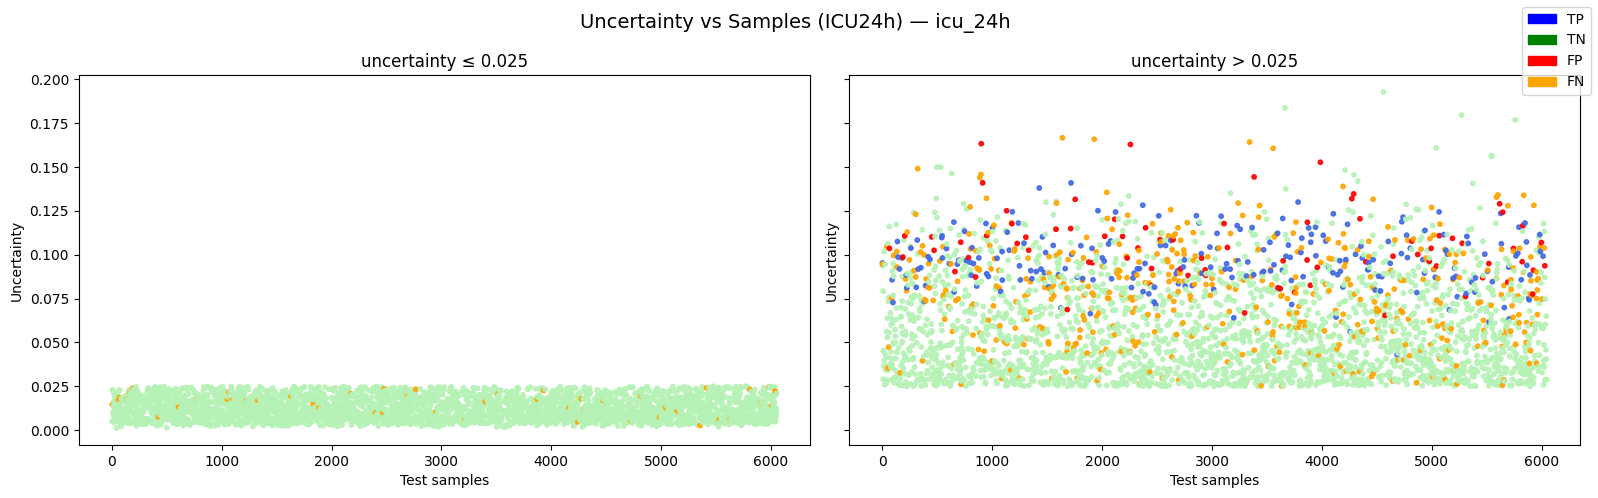

In [101]:


# -----------------------------
# SECOND LABEL ONLY (ICU24h)
# -----------------------------
target_idx = 1
target_name = lbl_itos_deterioration[target_idx]

y_true_l = y_true[:, target_idx]
y_prob_l = all_mean_preds[:, target_idx]
unc_l = all_uncertainties[:, target_idx]

mask = ~np.isnan(y_true_l)

y_true_l = y_true_l[mask]
y_prob_l = y_prob_l[mask]
unc_l = unc_l[mask]

# -----------------------------
# BINARY PREDICTION (needed for TP/FP/FN/TN)
# -----------------------------
y_pred_l = (y_prob_l >= 0.50).astype(int)

# -----------------------------
# CLASSIFY EACH SAMPLE
# -----------------------------
colors = []

for yt, yp in zip(y_true_l, y_pred_l):
    if yt == 1 and yp == 1:
        colors.append("royalblue")   # TP
    elif yt == 0 and yp == 0:
        colors.append("#b6f2b6")   # TN
    elif yt == 0 and yp == 1:
        colors.append("red")     # FP
    else:
        colors.append("orange")  # FN

colors = np.array(colors)

# -----------------------------
# SPLIT BY UNCERTAINTY
# -----------------------------
low_mask = unc_l <= 0.025
high_mask = unc_l > 0.025

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

groups = [
    ("uncertainty ≤ 0.025", low_mask, axes[0]),
    ("uncertainty > 0.025", high_mask, axes[1])
]

x = np.arange(len(y_true_l))

for title, m, ax in groups:

    ax.scatter(
        x[m],
        unc_l[m],
        c=colors[m],
        s=10,
        alpha=0.9
    )

    ax.set_title(title)
    ax.set_xlabel("Test samples")
    ax.set_ylabel("Uncertainty")

# legend (manual)
import matplotlib.patches as mpatches

legend_items = [
    mpatches.Patch(color="blue", label="TP"),
    mpatches.Patch(color="green", label="TN"),
    mpatches.Patch(color="red", label="FP"),
    mpatches.Patch(color="orange", label="FN"),
]

fig.legend(handles=legend_items, loc="upper right")

fig.suptitle(f"Uncertainty vs Samples (ICU24h) — {target_name}", fontsize=14)

plt.tight_layout()
plt.show()

In [99]:

classes = np.array(colors)

# -----------------------------
# SPLIT MASKS
# -----------------------------
low_mask = unc_l <= 0.05
high_mask = unc_l > 0.05

# -----------------------------
# COUNT FUNCTION
# -----------------------------
def count_metrics(mask):
    return {
        "TP": np.sum((classes == "blue") & mask),
        "TN": np.sum((classes == "green") & mask),
        "FP": np.sum((classes == "red") & mask),
        "FN": np.sum((classes == "orange") & mask),
    }

# -----------------------------
# CREATE TABLE
# -----------------------------
table = pd.DataFrame([
    count_metrics(low_mask),
    count_metrics(high_mask)
], index=[
    "uncertainty ≤ 0.05",
    "uncertainty > 0.05"
])

print(table)

                     TP    TN  FP   FN
uncertainty ≤ 0.05    1  4169   0  135
uncertainty > 0.05  222  1073  79  372


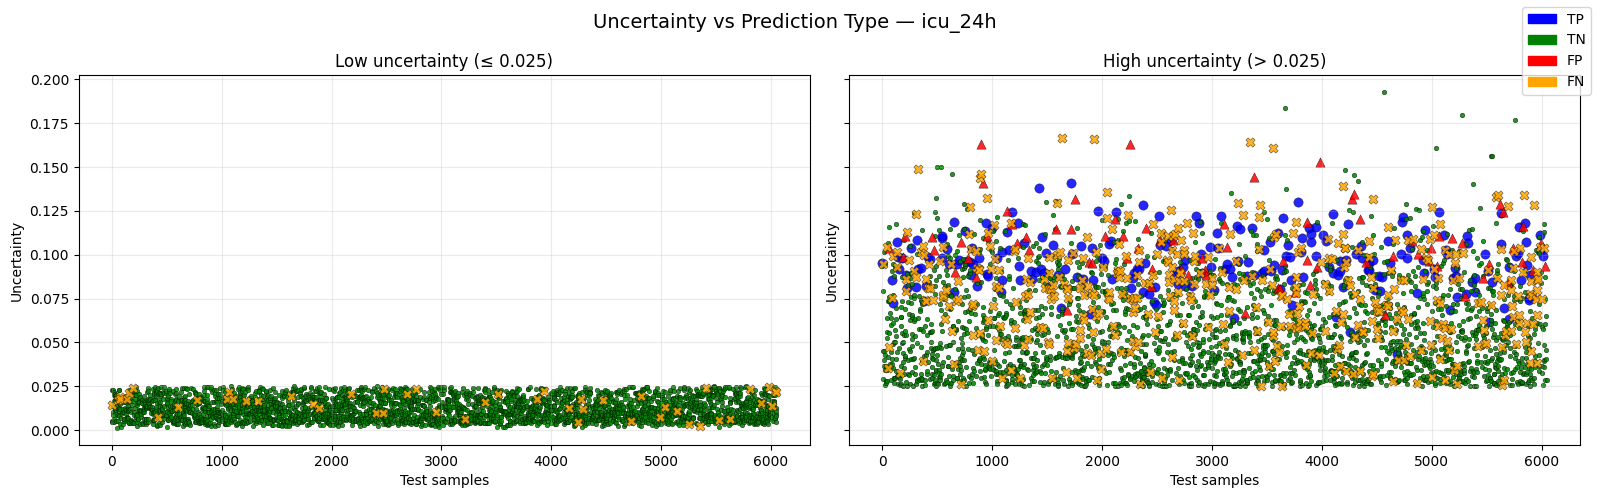

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

class_map = {
    "TP": ("blue", "o"),
    "TN": ("green", "."),
    "FP": ("red", "^"),
    "FN": ("orange", "X")
}

x = np.arange(len(y_true_l))

groups = [
    ("Low uncertainty (≤ 0.025)", low_mask, axes[0]),
    ("High uncertainty (> 0.025)", high_mask, axes[1])
]

for title, mask_group, ax in groups:

    for cls, (color, marker) in class_map.items():

        mask = (classes == cls) & mask_group

        ax.scatter(
            x[mask],
            unc_l[mask],
            c=color,
            marker=marker,
            s=45,              # bigger points = easier to see
            alpha=0.85,        # less fading for clarity
            edgecolors="black",
            linewidths=0.3
        )

    ax.set_title(title)
    ax.set_xlabel("Test samples")
    ax.set_ylabel("Uncertainty")
    ax.grid(alpha=0.25)

# clean legend
import matplotlib.patches as mpatches

legend_items = [
    mpatches.Patch(color="blue", label="TP"),
    mpatches.Patch(color="green", label="TN"),
    mpatches.Patch(color="red", label="FP"),
    mpatches.Patch(color="orange", label="FN"),
]

fig.legend(handles=legend_items, loc="upper right")

fig.suptitle(f"Uncertainty vs Prediction Type — {target_name}", fontsize=14)

plt.tight_layout()
plt.show()

# Threshold per uncertainty bucket

In [352]:
# ----------------------------------------
# align lengths upfront
# ----------------------------------------
min_len = min(len(y_test), len(pred_prob), len(uncertainty))

y_test_v      = y_test[:min_len]
pred_prob_v   = pred_prob[:min_len]
uncertainty_v = uncertainty[:min_len]

valid_mask    = ~np.isnan(y_test_v)

y_test_v      = y_test_v[valid_mask]
pred_prob_v   = pred_prob_v[valid_mask]
uncertainty_v = uncertainty_v[valid_mask]

# ----------------------------------------
# percentile thresholds
# ----------------------------------------
u_75 = np.percentile(uncertainty_v, 75)
u_90 = np.percentile(uncertainty_v, 90)
u_95 = np.percentile(uncertainty_v, 95)

# ----------------------------------------
# BEFORE: fixed threshold
# ----------------------------------------
y_pred_fixed = (pred_prob_v >= 0.14).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test_v, y_pred_fixed).ravel()

n          = len(y_test_v)
n_pos      = tp + fn
n_neg      = tn + fp
n_pred_pos = tp + fp

print("=" * 50)
print("BEFORE — fixed threshold (0.14)")
print("=" * 50)
print(f"  TP={tp}  FP={fp}  TN={tn}  FN={fn}")
print(f"  prevalence%       (pos/n)       : {100 * n_pos / n:.1f}%")
print(f"  sensitivity%      (TP/pos)      : {100 * tp / n_pos:.1f}%")
print(f"  precision%        (TP/(TP+FP))  : {100 * tp / n_pred_pos:.1f}%")
print(f"  FDR%              (FP/(TP+FP))  : {100 * fp / n_pred_pos:.1f}%")
print(f"  FN/(FN+TN)%                     : {100 * fn / (fn + tn):.1f}%")
print(f"  fall-out%         (FP/neg)      : {100 * fp / n_neg:.1f}%")
print(f"  specificity%      (TN/neg)      : {100 * tn / n_neg:.1f}%")

# ----------------------------------------
# AFTER: adaptive threshold
# ----------------------------------------
threshold = np.where(uncertainty_v > u_75, 0.40, 0.14)#                                       ↑ lower → fires more → catches more FN
y_pred_adapt = (pred_prob_v > threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test_v, y_pred_adapt).ravel()

n_pos      = tp + fn
n_neg      = tn + fp
n_pred_pos = tp + fp

print()
print("=" * 50)
print("AFTER — adaptive threshold (0.14 / 0.4 at u_75)")
print("=" * 50)
print(f"  TP={tp}  FP={fp}  TN={tn}  FN={fn}")
print(f"  prevalence%       (pos/n)       : {100 * n_pos / n:.1f}%")
print(f"  sensitivity%      (TP/pos)      : {100 * tp / n_pos:.1f}%")
print(f"  precision%        (TP/(TP+FP))  : {100 * tp / n_pred_pos:.1f}%")
print(f"  FDR%              (FP/(TP+FP))  : {100 * fp / n_pred_pos:.1f}%")
print(f"  FN/(FN+TN)%                     : {100 * fn / (fn + tn):.1f}%")
print(f"  fall-out%         (FP/neg)      : {100 * fp / n_neg:.1f}%")
print(f"  specificity%      (TN/neg)      : {100 * tn / n_neg:.1f}%")

BEFORE — fixed threshold (0.14)
  TP=587  FP=950  TN=4371  FN=143
  prevalence%       (pos/n)       : 12.1%
  sensitivity%      (TP/pos)      : 80.4%
  precision%        (TP/(TP+FP))  : 38.2%
  FDR%              (FP/(TP+FP))  : 61.8%
  FN/(FN+TN)%                     : 3.2%
  fall-out%         (FP/neg)      : 17.9%
  specificity%      (TN/neg)      : 82.1%

AFTER — adaptive threshold (0.14 / 0.4 at u_75)
  TP=402  FP=324  TN=4997  FN=328
  prevalence%       (pos/n)       : 12.1%
  sensitivity%      (TP/pos)      : 55.1%
  precision%        (TP/(TP+FP))  : 55.4%
  FDR%              (FP/(TP+FP))  : 44.6%
  FN/(FN+TN)%                     : 6.2%
  fall-out%         (FP/neg)      : 6.1%
  specificity%      (TN/neg)      : 93.9%


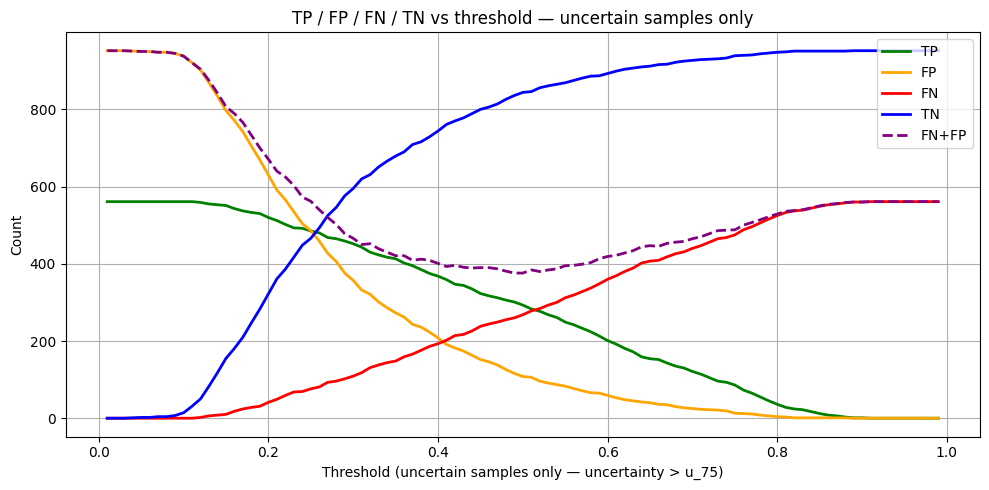

In [344]:
uncertain_mask = uncertainty_v > u_75

y_test_u      = y_test_v[uncertain_mask]
pred_prob_u   = pred_prob_v[uncertain_mask]
uncertainty_u = uncertainty_v[uncertain_mask]
# ----------------------------------------
# SWEEP: uncertain samples only
# ----------------------------------------
sweep_values = np.arange(0.01, 1.00, 0.01)

tps, fps, fns, tns = [], [], [], []

for t in sweep_values:
    y_pred = (pred_prob_u >= t).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_test_u, y_pred).ravel()
    tps.append(tp_)
    fps.append(fp_)
    fns.append(fn_)
    tns.append(tn_)

# ----------------------------------------
# PLOT
# ----------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(sweep_values, tps,                            label="TP",    color="green",  linewidth=2)
ax.plot(sweep_values, fps,                            label="FP",    color="orange", linewidth=2)
ax.plot(sweep_values, fns,                            label="FN",    color="red",    linewidth=2)
ax.plot(sweep_values, tns,                            label="TN",    color="blue",   linewidth=2)
ax.plot(sweep_values, np.array(fns) + np.array(fps),  label="FN+FP", color="purple", linewidth=2, linestyle="--")

#ax.axvline(0.1238, color="black", linestyle="--", linewidth=1.5, label="base threshold (0.1238)")

ax.set_xlabel("Threshold (uncertain samples only — uncertainty > u_75)")
ax.set_ylabel("Count")
ax.set_title("TP / FP / FN / TN vs threshold — uncertain samples only")
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

In [339]:
sensitivities, specificities = [], []

for t in sweep_values:
    y_pred = (pred_prob_u >= t).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_test_u, y_pred).ravel()

    tps.append(tp_)
    fps.append(fp_)
    fns.append(fn_)
    tns.append(tn_)

    # --- add these ---
    sensitivity = tp_ / (tp_ + fn_) if (tp_ + fn_) > 0 else 0
    specificity = tn_ / (tn_ + fp_) if (tn_ + fp_) > 0 else 0

    sensitivities.append(sensitivity)
    specificities.append(specificity)

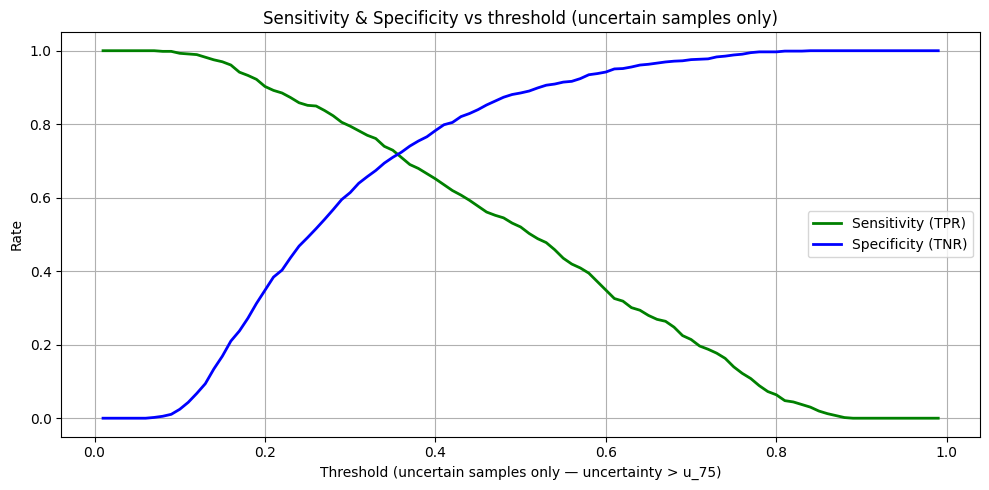

In [341]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(sweep_values, sensitivities, label="Sensitivity (TPR)", color="green", linewidth=2)
ax.plot(sweep_values, specificities, label="Specificity (TNR)", color="blue", linewidth=2)

#ax.axvline(0.1238, color="black", linestyle="--", linewidth=1.5, label="base threshold (0.1238)")

ax.set_xlabel("Threshold (uncertain samples only — uncertainty > u_75)")
ax.set_ylabel("Rate")
ax.set_title("Sensitivity & Specificity vs threshold (uncertain samples only)")
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

In [128]:
def mc_dropout_predict(model, test_loader, device, n_samples=50):

    model.train()  # IMPORTANT: keep dropout active

    all_mean_preds = []
    all_uncertainties = []
    all_labels = []
    all_mc_samples=[]

    with torch.no_grad():

        for cont, cat, labels in test_loader:

            cont = cont.to(device)
            cat  = cat.to(device)

            mc_samples = []

            # ----------------------------------------
            # Multiple stochastic forward passes
            # ----------------------------------------

            for _ in range(n_samples):
                out = model(static=cont, static_cat=cat)
                probs = torch.sigmoid(out["static"])
                mc_samples.append(probs.cpu().numpy())

            mc_samples = np.array(mc_samples)

            all_mc_samples.append(mc_samples)

            # -------------
            # 
            # ---------------------------
            # MC statistics
            # ----------------------------------------
            mean_preds = mc_samples.mean(axis=0)
            uncertainty = mc_samples.std(axis=0)

            all_mean_preds.append(mean_preds)
            all_uncertainties.append(uncertainty)
            all_labels.append(labels.numpy())

    all_mean_preds = np.concatenate(all_mean_preds, axis=0)
    all_uncertainties = np.concatenate(all_uncertainties, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    return (
    all_mean_preds,
    all_uncertainties,
    all_labels,
    all_mc_samples
)


In [ ]:
all_mean_preds, all_uncertainties, y_true, all_mc_samples = mc_dropout_predict(
    encoder,
    test_loader,
    device,
    n_samples=50
)
#all_mean_pred ## is 

In [145]:
y_pred = (all_mean_preds >= 0.5).astype(int)  # or your ROC threshold

y_error = (y_pred != y_true).astype(int)

In [147]:
y_error=y_error[:,1]

In [151]:
len(y_error)

6080